# FC PCA

Run matched no-SES and SES-residualized pMTG FC PCA workflows. Results are highly similar; no-SES results are reported in the manuscript.


In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('colorblind')
palette = sns.color_palette('colorblind')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 26,
    'axes.labelsize': 22,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})

network_colors = {
    'DMN': '#fb2e2e',
    'VAN': '#40cce9',
    'LANG': '#40cce9',
    'TPOLE': '#2e87ae',
    'AUD': '#ce8fff',
    'AMN': '#8a2edb',
    'DAN': '#2efe2e',
    'FP': '#ffff2e',
    'MTL': '#89fd89',
    'PMN': '#2e2eff',
    'PON': '#ebebeb',
    'SAL': '#2e2e2e',
    'SMd': '#8fffff',
    'SMH': '#8fffff',
    'SMM': '#ffa12e',
    'SML': '#ffa12e',
    'VIS': '#2e2eb3',
    'SMF': '#008611',
    'SCAN': '#863235'
}

FULL_NETWORKS = False


In [14]:
INVALID_CODES = (555, 777, 888, 999)

STANDARD_FC_COVARIATES = [
    'demo_sex_v2',
    'interview_age',
    'site_id_l',
    'ehi1b',
    'mean_fd_0.20',
]

DEFAULT_CATEGORICAL_COVARIATES = {
    'demo_sex_v2',
    'site_id_l',
    'ehi1b',
}


def standardize_subject_id(subject_ids):
    return (
        subject_ids.astype(str)
        .str.replace('_', '', regex=False)
        .str.replace('^sub-', '', regex=True)
    )


def load_motion_qa(motion_qa_path, motion_column='mean_fd_0.20'):
    motion_qa = pd.read_csv(motion_qa_path)
    motion_qa = motion_qa[['src_subject_id', motion_column]].copy()
    motion_qa['src_subject_id'] = standardize_subject_id(motion_qa['src_subject_id'])
    motion_qa = motion_qa.drop_duplicates(subset=['src_subject_id'])
    motion_qa[motion_column] = pd.to_numeric(motion_qa[motion_column], errors='coerce')
    return motion_qa


def merge_motion_qa(df, motion_qa_path, motion_column='mean_fd_0.20', how='left'):
    motion_qa = load_motion_qa(motion_qa_path, motion_column=motion_column)

    merged = df.copy()
    merged['src_subject_id'] = standardize_subject_id(merged['src_subject_id'])
    if motion_column in merged.columns:
        existing_motion = merged.groupby('src_subject_id')[motion_column].first()
        merged = merged.drop(columns=[motion_column])
        merged = merged.merge(motion_qa, on='src_subject_id', how=how)
        merged[motion_column] = merged[motion_column].fillna(
            merged['src_subject_id'].map(existing_motion)
        )
    else:
        merged = merged.merge(motion_qa, on='src_subject_id', how=how)
    return merged


def complete_covariate_mask(df, covariates, categorical_covariates=DEFAULT_CATEGORICAL_COVARIATES):
    categorical_covariates = set(categorical_covariates)
    complete = pd.Series(True, index=df.index) # Initialize a boolean Series to track completeness

    for covariate in covariates:
        is_categorical = df[covariate].dtype == 'object' or covariate in categorical_covariates
        if is_categorical:
            complete &= df[covariate].notna()
        else:
            complete &= pd.to_numeric(df[covariate], errors='coerce').notna()

    return complete


def encode_regression_covariates(df, covariates, categorical_covariates=DEFAULT_CATEGORICAL_COVARIATES):
    # Encode covariates for regression, handling categorical variables with one-hot encoding.
    encoded_parts = []
    categorical_covariates = set(categorical_covariates)

    for covariate in covariates:
        if df[covariate].dtype == 'object' or covariate in categorical_covariates:
            encoded_parts.append(
                pd.get_dummies(
                    df[covariate],
                    prefix=covariate,
                    drop_first=True,
                    dtype=float,
                )
            )
        else:
            encoded_parts.append(
                pd.to_numeric(df[covariate], errors='coerce').to_frame(covariate)
            )

    return pd.concat(encoded_parts, axis=1)


def residualize_fc_profiles(df, fc_columns, covariates=STANDARD_FC_COVARIATES):
    df = df.copy()
    covariate_complete = complete_covariate_mask(df, covariates) # Create a mask for rows with complete covariate data

    output_columns = [column + '_resid' for column in fc_columns]
    residuals = pd.DataFrame(np.nan, index=df.index, columns=output_columns)

    observed = df.loc[covariate_complete, fc_columns].to_numpy()
    covariate_matrix = encode_regression_covariates(
        df.loc[covariate_complete],
        covariates,
    )
    model = LinearRegression()
    model.fit(covariate_matrix, observed)
    predicted = model.predict(covariate_matrix)
    residuals.loc[covariate_complete, output_columns] = observed - predicted

    return pd.concat([df, residuals], axis=1)


In [15]:
if FULL_NETWORKS:
    DATA_PATH = '/Users/emk/Documents/Documents - Ron Weasley V/Research/Verbal-Ability/Final/wrangled_pMTG_FC_data_fullnetworks_meanFC.csv'
else:
    DATA_PATH = '/Users/emk/Documents/Documents - Ron Weasley V/Research/Verbal-Ability/Final/wrangled_pMTG_FC_data_midb61_meanFC.csv'
MOTION_QA_PATH = '/Users/emk/Documents/Documents - Ron Weasley V/Research/Verbal-Ability/Final/motion_QA_results.csv'
PCA_RESULTS_DIR = Path('/Users/emk/Documents/Documents - Ron Weasley V/Research/Verbal-Ability/Final/pca_results')
PCA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df = merge_motion_qa(df, MOTION_QA_PATH, how='left')
print(f'Loaded {len(df)} rows from {DATA_PATH}')


Loaded 2472 rows from /Users/emk/Documents/Documents - Ron Weasley V/Research/Verbal-Ability/Final/wrangled_pMTG_FC_data_midb61_meanFC.csv


## FC Analysis Settings

The SES model residualizes raw FC columns once with INR included alongside the standard FC covariates.


In [16]:
SES_RESIDUALIZATION_COVARIATE = 'inr'
N_FC_BOOTSTRAPS = 50000

# Only Fisher-z FC features are allowed in FC PCA; generated _full networks are dropped.
full_fc_cols = [column for column in df.columns if '_fz' in str(column) and '_full' in str(column)]
if full_fc_cols:
    df = df.drop(columns=full_fc_cols)
print(f'Dropped {len(full_fc_cols)} generated full-network Fisher-z FC columns from the FC PCA dataframe.')

raw_fc_cols = [col for col in df.columns if col.endswith('_fz') and '_full' not in col]

FC_PCA_COVARIATES = [
    'demo_sex_v2',
    'interview_age',
    'site_id_l',
    'ehi1b',
    'mean_fd_0.20',
]

PCA_MODEL_SPECS = [
    {
        'model_name': 'without_ses_residualization',
        'label': 'No SES residualization',
        'short_label': 'No SES',
        'prefix': 'no_ses',
        'fc_covariates': FC_PCA_COVARIATES,
    },
    {
        'model_name': 'with_ses_residualization',
        'label': 'SES residualization',
        'short_label': 'SES',
        'prefix': 'ses',
        'fc_covariates': FC_PCA_COVARIATES + [SES_RESIDUALIZATION_COVARIATE],
    },
]

print(f'Raw FC columns available for PCA: {len(raw_fc_cols)}')
print('FC PCA model specs:')
for spec in PCA_MODEL_SPECS:
    print(f"- {spec['model_name']}")
    print(f"  FC covariates: {spec['fc_covariates']}")


Dropped 0 generated full-network Fisher-z FC columns from the FC PCA dataframe.
Raw FC columns available for PCA: 56
FC PCA model specs:
- without_ses_residualization
  FC covariates: ['demo_sex_v2', 'interview_age', 'site_id_l', 'ehi1b', 'mean_fd_0.20']
- with_ses_residualization
  FC covariates: ['demo_sex_v2', 'interview_age', 'site_id_l', 'ehi1b', 'mean_fd_0.20', 'inr']


## Shared FC PCA Helpers


In [17]:
def residualize_fc_variant(data, raw_columns, covariates, output_suffix):
    """Residualize raw FC columns once using the full covariate set."""
    helper_output_cols = [f'{col}_resid' for col in raw_columns]
    output_cols = [f'{col}_{output_suffix}_resid' for col in raw_columns]

    helper_input = data.drop(columns=helper_output_cols, errors='ignore')
    helper_output = residualize_fc_profiles(
        helper_input,
        raw_columns,
        covariates=covariates,
    )

    residualized = data.copy()
    for helper_col, output_col in zip(helper_output_cols, output_cols):
        residualized[output_col] = pd.to_numeric(helper_output[helper_col], errors='coerce')
    return residualized, output_cols


def attach_score_columns(data, scores):
    updated = data.copy()
    for score_col in scores.columns:
        updated[score_col] = scores[score_col]
    return updated


def strip_fc_resid_suffix(column):
    text = str(column)
    for suffix in ('_no_ses_resid', '_ses_resid', '_resid'):
        if text.endswith(suffix):
            return text[: -len(suffix)]
    return text


def parsed_fc_parts(column):
    # returns the base network and hemisphere from FC column names
    parts = strip_fc_resid_suffix(column).split('_')
    return parts[0], parts[1]


def plot_label_for(base_net, net_hemi):
    base = base_net.upper()
    hemi = net_hemi.lower()

    if base == 'CO':
        base = 'AMN'
    if base == 'SMD':
        base = 'SMd'
    if base == 'SML':
        base = 'SMl'
    if base == 'TPOLE':
        base = 'TPOLE'

    if base == 'VAN' and hemi == 'left':
        return 'LANG'
    if base == 'VAN' and hemi == 'right':
        return 'VAN'

    return base


def build_fc_plot_groups(feature_cols):
    base_nets_present = sorted({parsed_fc_parts(col)[0].upper() for col in feature_cols})

    plot_groups = []
    for base in base_nets_present:
        if base == 'VAN':
            plot_groups.append((base, 'left_avg', 'LANG'))
            plot_groups.append((base, 'right_avg', 'VAN'))
        else:
            plot_groups.append((base, 'avg', plot_label_for(base, 'left')))

    xlabels = [label for _, _, label in plot_groups]
    return plot_groups, xlabels


def pick_fc_index(feature_cols, base_net, net_hemi, pmtg_hemi):
    token = f'_{pmtg_hemi}_'
    matches = [
        i for i, col in enumerate(feature_cols)
        if parsed_fc_parts(col)[0].upper() == base_net.upper()
        and parsed_fc_parts(col)[1].lower() == net_hemi.lower()
        and token in strip_fc_resid_suffix(col)
    ]
    return matches[0]


def run_fc_pca_with_bootstrap(data, feature_cols, analysis_label, score_prefix, n_boot=N_FC_BOOTSTRAPS):
    print(f'Found {len(feature_cols)} {analysis_label} FC features for PCA.')

    fc_input = data[feature_cols].apply(pd.to_numeric, errors='coerce')
    fc_complete = fc_input.dropna().copy()
    print(f'{analysis_label} complete FC rows for PCA: {len(fc_complete)}/{len(fc_input)}')

    fc_centered = fc_complete - fc_complete.mean()
    x_matrix = fc_centered.to_numpy()
    n_features = x_matrix.shape[1]

    pca = PCA(random_state=42)
    scores_array = pca.fit_transform(x_matrix)
    reference_components = pca.components_
    n_components = reference_components.shape[0]

    loadings = (pca.components_.T * np.sqrt(pca.explained_variance_)).T

    boot_loadings = np.zeros((n_boot, n_components, n_features))
    boot_var_exp = np.zeros((n_boot, n_components))

    for boot_idx in range(n_boot):
        sample_idx = np.random.choice(x_matrix.shape[0], size=x_matrix.shape[0], replace=True)
        x_sample = x_matrix[sample_idx, :]

        boot_pca = PCA(random_state=42)
        boot_pca.fit(x_sample)
        boot_components = boot_pca.components_
        boot_var_exp[boot_idx, :] = boot_pca.explained_variance_ratio_

        boot_true = (boot_components.T * np.sqrt(boot_pca.explained_variance_)).T # Compute loadings for the bootstrap sample
        for pc_idx in range(n_components):
            if np.corrcoef(reference_components[pc_idx], boot_components[pc_idx])[0, 1] < 0: # If the correlation between the reference and bootstrap components is negative, flip the sign of the bootstrap loadings to align with the reference.
                boot_true[pc_idx] *= -1

        boot_loadings[boot_idx, :, :] = boot_true

    ci_lower = np.percentile(boot_loadings, 2.5, axis=0)
    ci_upper = np.percentile(boot_loadings, 97.5, axis=0)
    var_exp_std = np.std(boot_var_exp, axis=0)

    score_cols = [f'{score_prefix}_PC{i + 1}' for i in range(scores_array.shape[1])]
    scores = pd.DataFrame(np.nan, index=fc_input.index, columns=score_cols, dtype=float)
    scores.loc[fc_complete.index, score_cols] = scores_array

    result = {
        'input': fc_input,
        'complete_input': fc_complete,
        'centered_input': fc_centered,
        'X': x_matrix,
        'pca': pca,
        'score_cols': score_cols,
        'scores': scores,
        'loadings': loadings,
        'boot_loadings': boot_loadings,
        'boot_var_exp': boot_var_exp,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'var_exp': pca.explained_variance_ratio_,
        'var_exp_std': var_exp_std,
    }

    print('\nVariance explained per PC:')
    for pc_idx in range(min(10, n_components)):
        print(
            f"PC{pc_idx + 1}: {result['var_exp'][pc_idx] * 100:.2f}% "
            f"(± {var_exp_std[pc_idx] * 100:.2f}%)"
        )

    plot_fc_loading_summaries(feature_cols, analysis_label, result)
    plot_fc_cumulative_variance(result, f'{analysis_label} Cumulative Variance Explained')
    print_fc_variance_table(result, f'{analysis_label} variance explained by each component')

    return result


def plot_fc_loading_summaries(feature_cols, analysis_label, result):
    loadings = result['loadings']
    boot_loadings = result['boot_loadings']
    ci_lower = result['ci_lower']
    ci_upper = result['ci_upper']
    n_pcs = loadings.shape[0]

    left_features = [i for i, col in enumerate(feature_cols) if '_L_' in strip_fc_resid_suffix(col)]
    right_features = [i for i, col in enumerate(feature_cols) if '_R_' in strip_fc_resid_suffix(col)]

    print(f'\nIdentified {len(left_features)} left pMTG')
    print(f'Identified {len(right_features)} right pMTG')
    print('\n===== OUTPUT SEPARATED BY _L_ AND _R_ FEATURES =====')

    plot_groups, xlabels = build_fc_plot_groups(feature_cols)

    for pc_idx in range(min(10, n_pcs)):
        print(f'\n=========== {analysis_label} PC{pc_idx + 1} ===========\n')

        print('Top left pMTG features:')
        left_load = np.abs(loadings[pc_idx, left_features])
        left_sorted = np.argsort(left_load)[-12:][::-1]
        for idx in left_sorted:
            feature_idx = left_features[idx]
            feature = feature_cols[feature_idx]
            mean_loading = loadings[pc_idx, feature_idx]
            lower = ci_lower[pc_idx, feature_idx]
            upper = ci_upper[pc_idx, feature_idx]
            print(f'  {feature}: {mean_loading:.4f} [{lower:.4f}, {upper:.4f}]')

        print('\nTop right pMTG features:')
        right_load = np.abs(loadings[pc_idx, right_features])
        right_sorted = np.argsort(right_load)[-12:][::-1]
        for idx in right_sorted:
            feature_idx = right_features[idx]
            feature = feature_cols[feature_idx]
            mean_loading = loadings[pc_idx, feature_idx]
            lower = ci_lower[pc_idx, feature_idx]
            upper = ci_upper[pc_idx, feature_idx]
            print(f'  {feature}: {mean_loading:.4f} [{lower:.4f}, {upper:.4f}]')

        plot_fc_loading_bars(
            feature_cols,
            pc_idx,
            loadings,
            boot_loadings,
            plot_groups,
            xlabels,
        )


def plot_fc_loading_bars(feature_cols, pc_idx, loadings, boot_loadings, plot_groups, xlabels):
    x_values = np.arange(len(plot_groups))
    width = 0.38
    pmtg_left_means = []
    pmtg_right_means = []
    pmtg_left_err_lo = []
    pmtg_left_err_hi = []
    pmtg_right_err_lo = []
    pmtg_right_err_hi = []

    for base_net, group_mode, label in plot_groups:
        if group_mode == 'avg':
            left_indices = [
                pick_fc_index(feature_cols, base_net, 'left', 'L'),
                pick_fc_index(feature_cols, base_net, 'right', 'L'),
            ]
            right_indices = [
                pick_fc_index(feature_cols, base_net, 'left', 'R'),
                pick_fc_index(feature_cols, base_net, 'right', 'R'),
            ]
            left_boot = boot_loadings[:, pc_idx, left_indices].mean(axis=1)
            right_boot = boot_loadings[:, pc_idx, right_indices].mean(axis=1)
            left_mean = loadings[pc_idx, left_indices].mean()
            right_mean = loadings[pc_idx, right_indices].mean()
        elif group_mode == 'left_avg':
            left_indices = [pick_fc_index(feature_cols, base_net, 'left', 'L')]
            right_indices = [pick_fc_index(feature_cols, base_net, 'left', 'R')]
            left_boot = boot_loadings[:, pc_idx, left_indices[0]]
            right_boot = boot_loadings[:, pc_idx, right_indices[0]]
            left_mean = loadings[pc_idx, left_indices[0]]
            right_mean = loadings[pc_idx, right_indices[0]]
        elif group_mode == 'right_avg':
            left_indices = [pick_fc_index(feature_cols, base_net, 'right', 'L')]
            right_indices = [pick_fc_index(feature_cols, base_net, 'right', 'R')]
            left_boot = boot_loadings[:, pc_idx, left_indices[0]]
            right_boot = boot_loadings[:, pc_idx, right_indices[0]]
            left_mean = loadings[pc_idx, left_indices[0]]
            right_mean = loadings[pc_idx, right_indices[0]]
        left_lo, left_hi = np.percentile(left_boot, [2.5, 97.5])
        right_lo, right_hi = np.percentile(right_boot, [2.5, 97.5])

        pmtg_left_means.append(left_mean)
        pmtg_left_err_lo.append(max(left_mean - left_lo, 0))
        pmtg_left_err_hi.append(max(left_hi - left_mean, 0))
        pmtg_right_means.append(right_mean)
        pmtg_right_err_lo.append(max(right_mean - right_lo, 0))
        pmtg_right_err_hi.append(max(right_hi - right_mean, 0))

    plt.figure(figsize=(18, 6))
    plt.bar(
        x_values - width / 2,
        pmtg_left_means,
        width,
        yerr=[pmtg_left_err_lo, pmtg_left_err_hi],
        capsize=4,
        color=[network_colors.get(label, 'steelblue') for _, _, label in plot_groups],
        hatch='\\',
        edgecolor='black',
        linewidth=0.8,
    )
    plt.bar(
        x_values + width / 2,
        pmtg_right_means,
        width,
        yerr=[pmtg_right_err_lo, pmtg_right_err_hi],
        capsize=4,
        color=[network_colors.get(label, 'steelblue') for _, _, label in plot_groups],
        hatch='//',
        edgecolor='black',
        linewidth=0.8,
    )

    plt.xticks(x_values, xlabels, rotation=45, ha='right')
    plt.title(f'PC{pc_idx + 1} Loadings')
    plt.ylabel('Correlation with PC')
    plt.axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()
    plt.close()


def plot_fc_cumulative_variance(fc_result, title):
    plt.figure(figsize=(18, 10))
    plt.plot(np.cumsum(fc_result['pca'].explained_variance_ratio_), marker='o', color='black')
    plt.title(title)
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.xticks(np.arange(0, 25, 1))
    plt.yticks(np.arange(0, 1.1, 0.1))
    xticks = plt.xticks()[0]
    xtick_labels = [str(int(x) + 1) for x in xticks]
    plt.xticks(xticks, xtick_labels)
    plt.xlim(0, 24)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    plt.close()


def print_fc_variance_table(fc_result, title):
    print(title + ':')
    for idx, variance in enumerate(fc_result['pca'].explained_variance_ratio_):
        print(f'Component {idx + 1}: {variance:.4f} ({variance * 100:.2f}%)')
    print('Sum of first 10 components:', np.sum(fc_result['pca'].explained_variance_ratio_[:10]))


## Matched FC PCA Workflows


\n==========================================================================================
No SES residualization
FC covariates: ['demo_sex_v2', 'interview_age', 'site_id_l', 'ehi1b', 'mean_fd_0.20']
Found 56 No SES FC PCA FC features for PCA.
No SES FC PCA complete FC rows for PCA: 2472/2472

Variance explained per PC:
PC1: 34.26% (± 0.64%)
PC2: 11.31% (± 0.31%)
PC3: 8.59% (± 0.26%)
PC4: 6.26% (± 0.18%)
PC5: 4.09% (± 0.12%)
PC6: 3.78% (± 0.11%)
PC7: 3.40% (± 0.10%)
PC8: 2.39% (± 0.06%)
PC9: 2.28% (± 0.06%)
PC10: 2.11% (± 0.06%)

Identified 28 left pMTG
Identified 28 right pMTG

===== OUTPUT SEPARATED BY _L_ AND _R_ FEATURES =====

=========== No SES FC PCA PC1 ===========

Top left pMTG features:
  DMN_left_L_fz_no_ses_resid: 0.2420 [0.2331, 0.2504]
  DMN_right_L_fz_no_ses_resid: 0.2111 [0.2031, 0.2188]
  CO_left_L_fz_no_ses_resid: -0.1955 [-0.2035, -0.1871]
  CO_right_L_fz_no_ses_resid: -0.1901 [-0.1978, -0.1822]
  DAN_left_L_fz_no_ses_resid: -0.1481 [-0.1567, -0.1394]
  DAN_right_

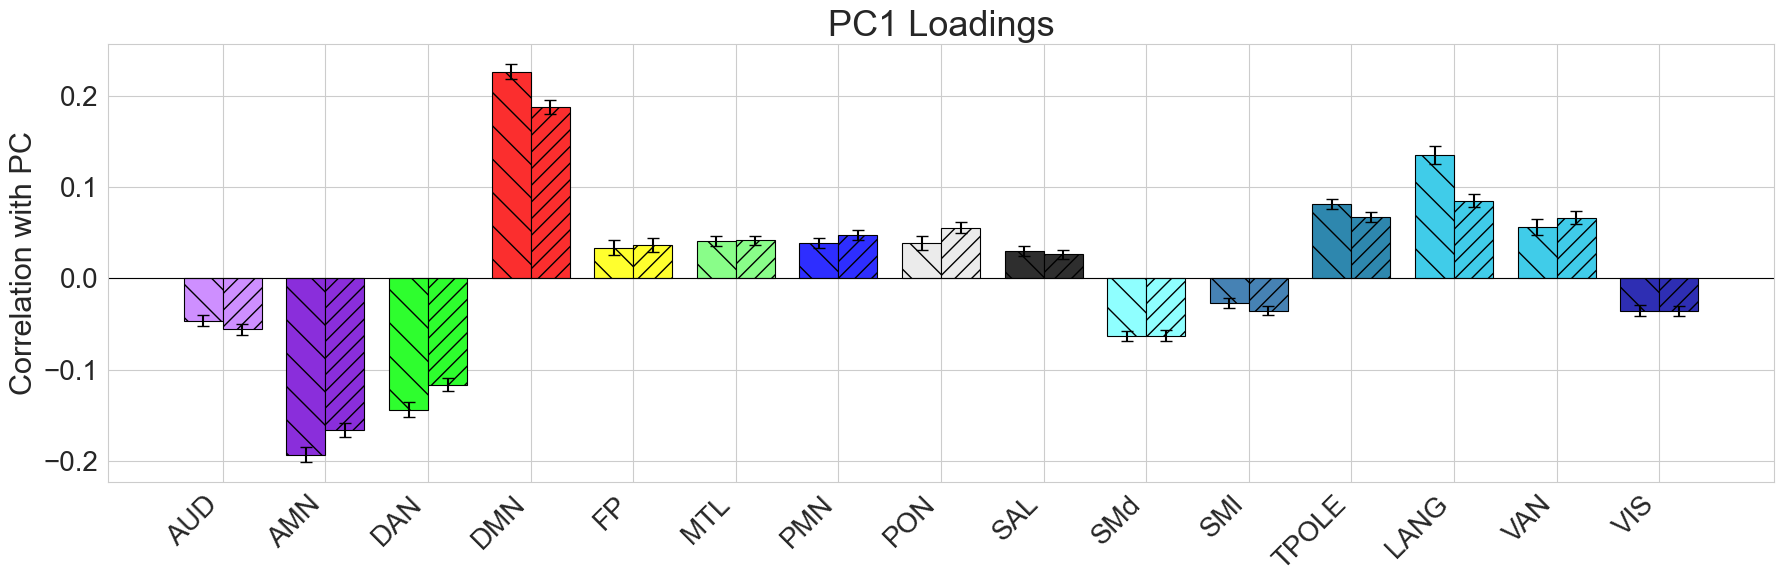


=========== No SES FC PCA PC2 ===========

Top left pMTG features:
  VAN_left_L_fz_no_ses_resid: 0.1368 [0.1279, 0.1443]
  VAN_right_L_fz_no_ses_resid: 0.1181 [0.1106, 0.1246]
  DAN_left_L_fz_no_ses_resid: -0.1114 [-0.1192, -0.1021]
  DAN_right_L_fz_no_ses_resid: -0.1015 [-0.1099, -0.0916]
  Aud_right_L_fz_no_ses_resid: 0.0741 [0.0636, 0.0830]
  Aud_left_L_fz_no_ses_resid: 0.0736 [0.0628, 0.0827]
  PON_right_L_fz_no_ses_resid: -0.0613 [-0.0719, -0.0495]
  PON_left_L_fz_no_ses_resid: -0.0600 [-0.0709, -0.0478]
  FP_left_L_fz_no_ses_resid: -0.0590 [-0.0720, -0.0451]
  Tpole_left_L_fz_no_ses_resid: 0.0586 [0.0509, 0.0655]
  Sal_left_L_fz_no_ses_resid: 0.0534 [0.0461, 0.0600]
  SMl_right_L_fz_no_ses_resid: 0.0531 [0.0447, 0.0603]

Top right pMTG features:
  CO_right_R_fz_no_ses_resid: 0.0804 [0.0652, 0.0939]
  CO_left_R_fz_no_ses_resid: 0.0803 [0.0678, 0.0913]
  Aud_right_R_fz_no_ses_resid: 0.0731 [0.0670, 0.0785]
  FP_right_R_fz_no_ses_resid: -0.0707 [-0.0822, -0.0585]
  Aud_left_R_fz_no

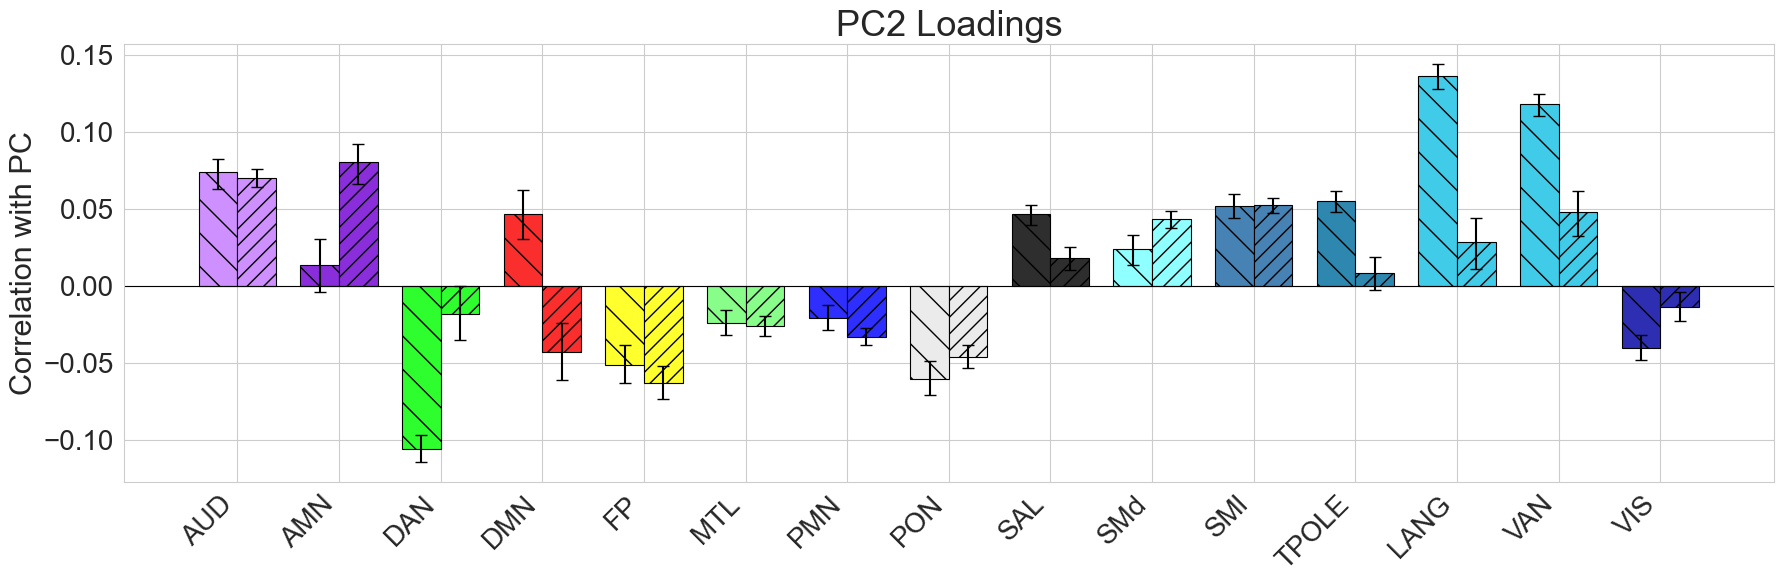


=========== No SES FC PCA PC3 ===========

Top left pMTG features:
  CO_left_L_fz_no_ses_resid: 0.0908 [0.0812, 0.0983]
  DMN_left_L_fz_no_ses_resid: -0.0895 [-0.0970, -0.0798]
  CO_right_L_fz_no_ses_resid: 0.0895 [0.0809, 0.0961]
  DMN_right_L_fz_no_ses_resid: -0.0807 [-0.0872, -0.0724]
  Aud_left_L_fz_no_ses_resid: 0.0465 [0.0342, 0.0578]
  Aud_right_L_fz_no_ses_resid: 0.0438 [0.0314, 0.0553]
  SMd_left_L_fz_no_ses_resid: 0.0415 [0.0336, 0.0487]
  PON_left_L_fz_no_ses_resid: -0.0406 [-0.0542, -0.0260]
  SMd_right_L_fz_no_ses_resid: 0.0401 [0.0319, 0.0474]
  PON_right_L_fz_no_ses_resid: -0.0389 [-0.0527, -0.0243]
  SMl_left_L_fz_no_ses_resid: 0.0347 [0.0254, 0.0434]
  FP_left_L_fz_no_ses_resid: -0.0335 [-0.0533, -0.0128]

Top right pMTG features:
  DMN_left_R_fz_no_ses_resid: 0.1033 [0.0952, 0.1092]
  DMN_right_R_fz_no_ses_resid: 0.0967 [0.0877, 0.1035]
  DAN_right_R_fz_no_ses_resid: -0.0961 [-0.1030, -0.0876]
  DAN_left_R_fz_no_ses_resid: -0.0911 [-0.0974, -0.0832]
  VAN_left_R_fz_n

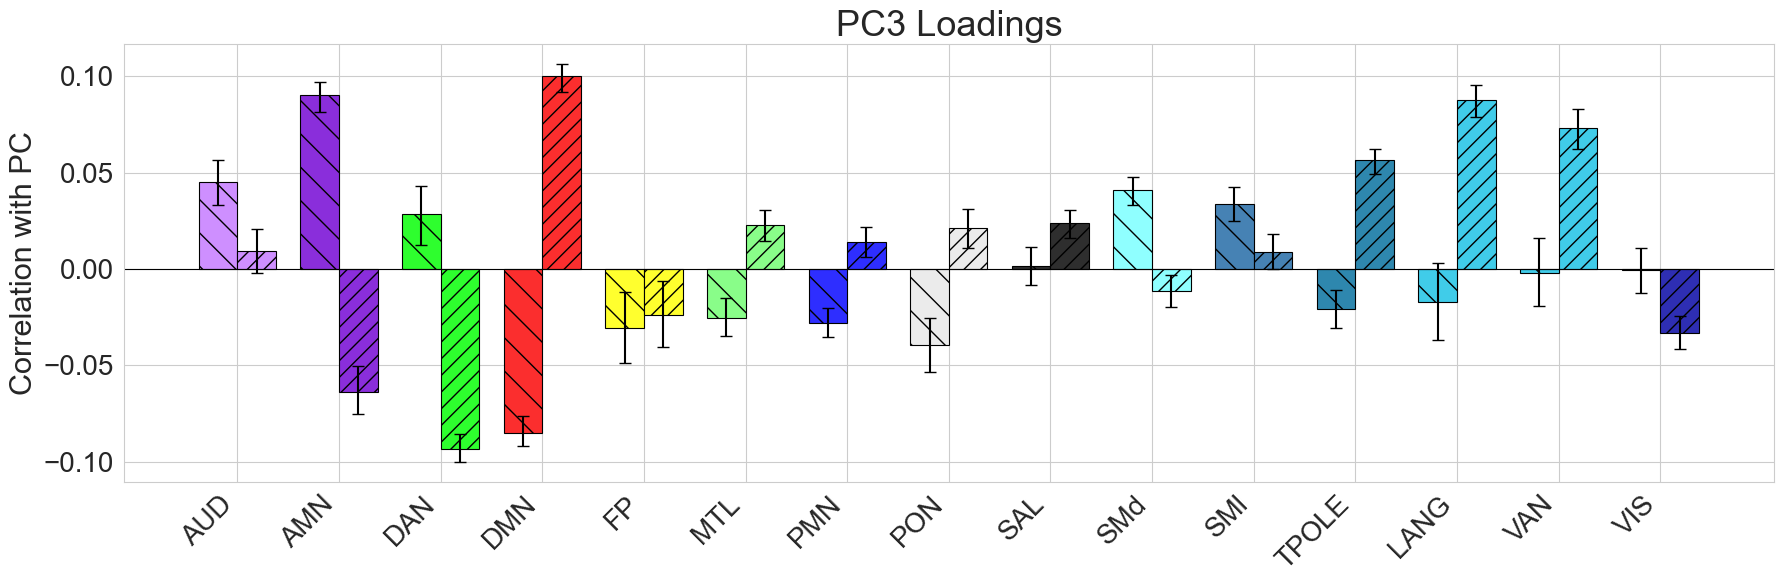


=========== No SES FC PCA PC4 ===========

Top left pMTG features:
  FP_left_L_fz_no_ses_resid: 0.1190 [0.1083, 0.1278]
  FP_right_L_fz_no_ses_resid: 0.0993 [0.0901, 0.1070]
  PON_right_L_fz_no_ses_resid: -0.0610 [-0.0715, -0.0493]
  PON_left_L_fz_no_ses_resid: -0.0609 [-0.0719, -0.0487]
  Vis_right_L_fz_no_ses_resid: -0.0608 [-0.0682, -0.0525]
  Vis_left_L_fz_no_ses_resid: -0.0583 [-0.0660, -0.0499]
  MTL_left_L_fz_no_ses_resid: -0.0528 [-0.0602, -0.0445]
  MTL_right_L_fz_no_ses_resid: -0.0526 [-0.0595, -0.0446]
  Sal_right_L_fz_no_ses_resid: 0.0404 [0.0321, 0.0480]
  Sal_left_L_fz_no_ses_resid: 0.0404 [0.0313, 0.0488]
  CO_left_L_fz_no_ses_resid: 0.0388 [0.0258, 0.0513]
  Tpole_left_L_fz_no_ses_resid: -0.0374 [-0.0441, -0.0301]

Top right pMTG features:
  FP_right_R_fz_no_ses_resid: 0.1012 [0.0916, 0.1093]
  FP_left_R_fz_no_ses_resid: 0.0916 [0.0835, 0.0984]
  Vis_right_R_fz_no_ses_resid: -0.0448 [-0.0528, -0.0362]
  Vis_left_R_fz_no_ses_resid: -0.0416 [-0.0497, -0.0330]
  MTL_left_

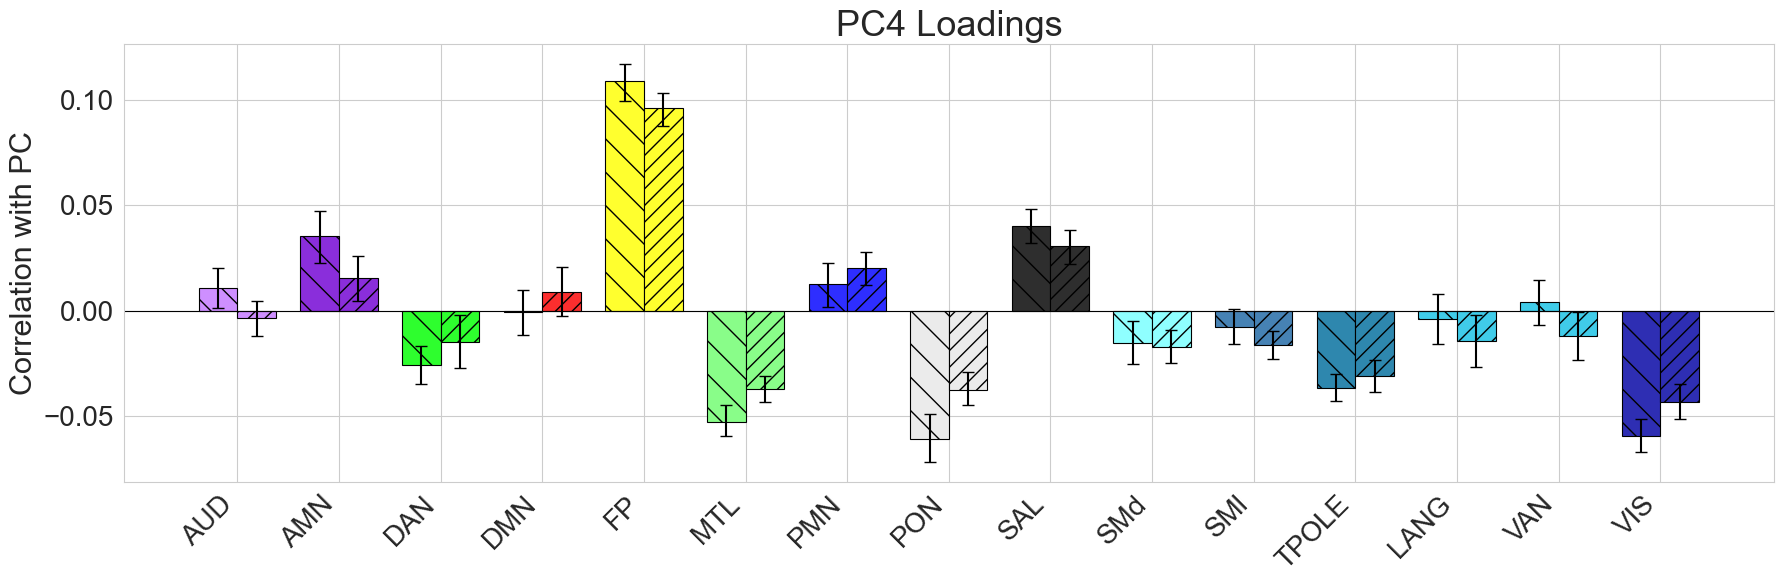


=========== No SES FC PCA PC5 ===========

Top left pMTG features:
  PON_left_L_fz_no_ses_resid: 0.0768 [0.0481, 0.0853]
  PMN_left_L_fz_no_ses_resid: 0.0727 [0.0369, 0.0803]
  PON_right_L_fz_no_ses_resid: 0.0727 [0.0453, 0.0810]
  PMN_right_L_fz_no_ses_resid: 0.0698 [0.0372, 0.0765]
  VAN_left_L_fz_no_ses_resid: -0.0503 [-0.0677, -0.0144]
  SMd_right_L_fz_no_ses_resid: -0.0401 [-0.0597, -0.0058]
  MTL_left_L_fz_no_ses_resid: 0.0376 [0.0195, 0.0474]
  SMd_left_L_fz_no_ses_resid: -0.0368 [-0.0561, -0.0047]
  Sal_right_L_fz_no_ses_resid: 0.0345 [0.0037, 0.0483]
  MTL_right_L_fz_no_ses_resid: 0.0325 [0.0159, 0.0422]
  Sal_left_L_fz_no_ses_resid: 0.0290 [-0.0052, 0.0476]
  VAN_right_L_fz_no_ses_resid: -0.0290 [-0.0569, 0.0092]

Top right pMTG features:
  CO_right_R_fz_no_ses_resid: 0.0515 [0.0290, 0.0590]
  DAN_right_R_fz_no_ses_resid: -0.0512 [-0.0614, -0.0247]
  CO_left_R_fz_no_ses_resid: 0.0510 [0.0268, 0.0595]
  DAN_left_R_fz_no_ses_resid: -0.0476 [-0.0592, -0.0209]
  Sal_left_R_fz_no

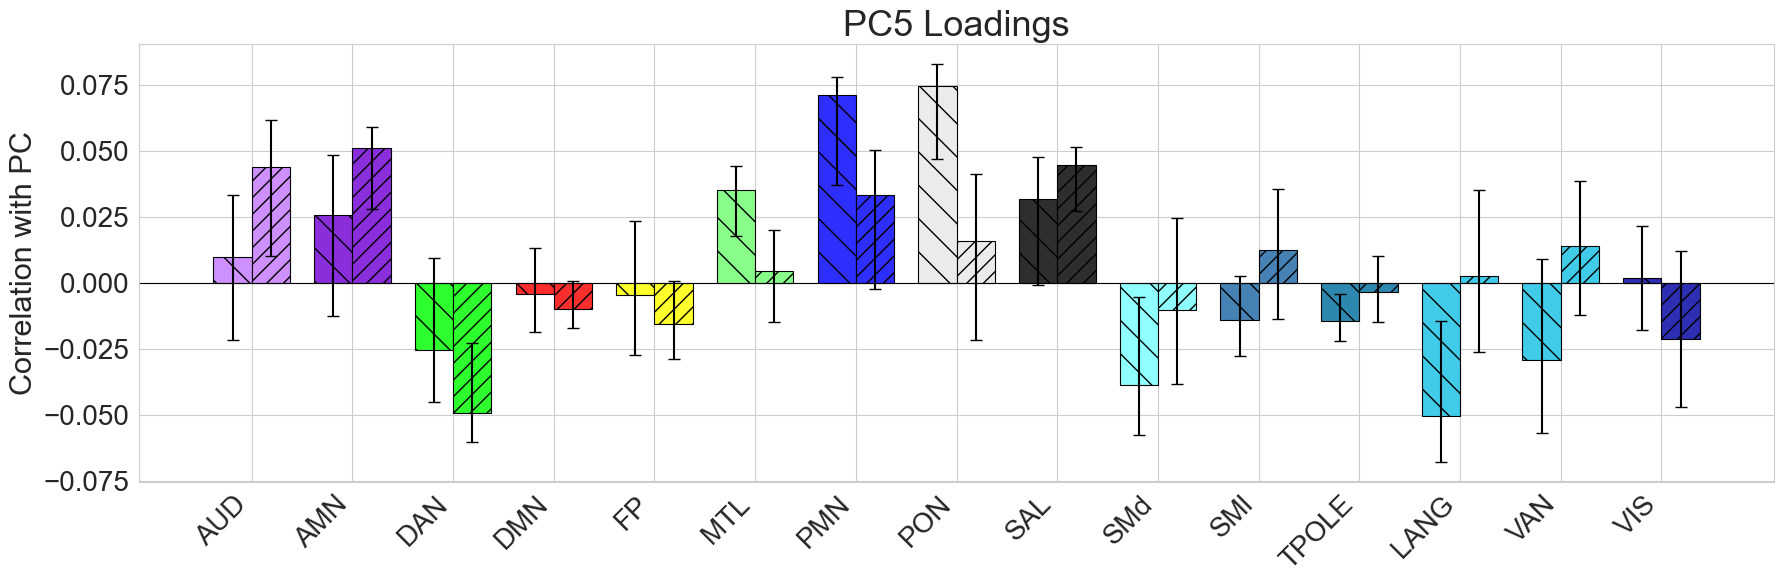


=========== No SES FC PCA PC6 ===========

Top left pMTG features:
  VAN_right_L_fz_no_ses_resid: 0.0524 [0.0173, 0.0653]
  CO_left_L_fz_no_ses_resid: 0.0480 [0.0222, 0.0567]
  CO_right_L_fz_no_ses_resid: 0.0435 [0.0184, 0.0528]
  DAN_left_L_fz_no_ses_resid: -0.0430 [-0.0527, -0.0168]
  VAN_left_L_fz_no_ses_resid: 0.0399 [-0.0057, 0.0648]
  DAN_right_L_fz_no_ses_resid: -0.0395 [-0.0502, -0.0131]
  Sal_left_L_fz_no_ses_resid: 0.0380 [0.0124, 0.0507]
  Aud_right_L_fz_no_ses_resid: 0.0378 [0.0051, 0.0546]
  FP_left_L_fz_no_ses_resid: -0.0376 [-0.0485, -0.0174]
  Aud_left_L_fz_no_ses_resid: 0.0375 [0.0067, 0.0526]
  FP_right_L_fz_no_ses_resid: -0.0338 [-0.0431, -0.0162]
  SMd_right_L_fz_no_ses_resid: -0.0316 [-0.0615, 0.0070]

Top right pMTG features:
  SMd_right_R_fz_no_ses_resid: -0.0499 [-0.0622, -0.0232]
  PON_right_R_fz_no_ses_resid: 0.0466 [0.0159, 0.0583]
  VAN_left_R_fz_no_ses_resid: -0.0451 [-0.0599, -0.0117]
  Vis_left_R_fz_no_ses_resid: 0.0444 [0.0120, 0.0600]
  SMd_left_R_fz_n

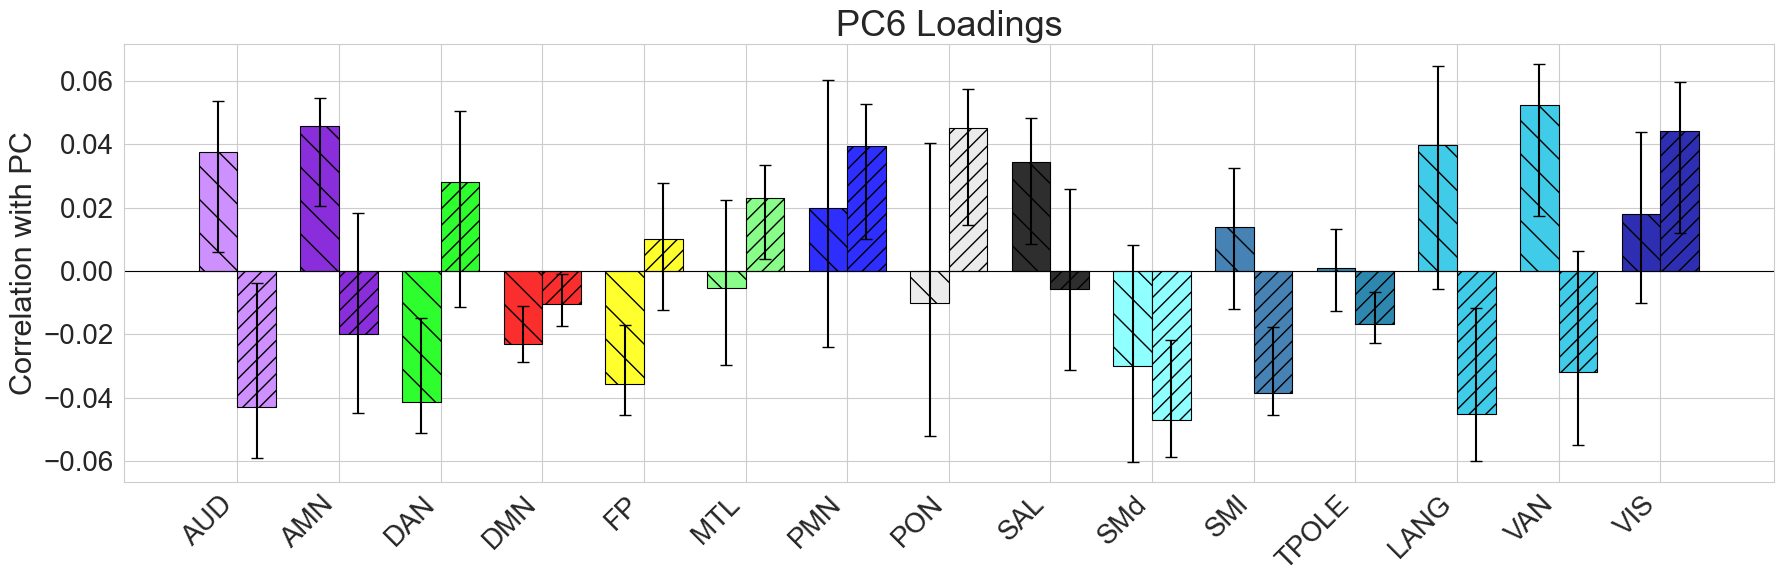


=========== No SES FC PCA PC7 ===========

Top left pMTG features:
  SMd_left_L_fz_no_ses_resid: 0.0624 [0.0396, 0.0735]
  Vis_left_L_fz_no_ses_resid: -0.0598 [-0.0677, -0.0418]
  SMd_right_L_fz_no_ses_resid: 0.0591 [0.0352, 0.0712]
  Vis_right_L_fz_no_ses_resid: -0.0576 [-0.0656, -0.0398]
  Aud_right_L_fz_no_ses_resid: 0.0487 [0.0286, 0.0613]
  SMl_left_L_fz_no_ses_resid: 0.0449 [0.0321, 0.0528]
  Aud_left_L_fz_no_ses_resid: 0.0443 [0.0247, 0.0574]
  SMl_right_L_fz_no_ses_resid: 0.0434 [0.0306, 0.0512]
  MTL_left_L_fz_no_ses_resid: 0.0333 [0.0191, 0.0426]
  VAN_left_L_fz_no_ses_resid: -0.0326 [-0.0488, -0.0065]
  MTL_right_L_fz_no_ses_resid: 0.0308 [0.0176, 0.0395]
  PON_left_L_fz_no_ses_resid: 0.0298 [0.0094, 0.0446]

Top right pMTG features:
  VAN_right_R_fz_no_ses_resid: -0.0606 [-0.0711, -0.0407]
  VAN_left_R_fz_no_ses_resid: -0.0450 [-0.0610, -0.0221]
  Vis_left_R_fz_no_ses_resid: -0.0385 [-0.0531, -0.0125]
  Vis_right_R_fz_no_ses_resid: -0.0373 [-0.0520, -0.0115]
  SMd_right_R_

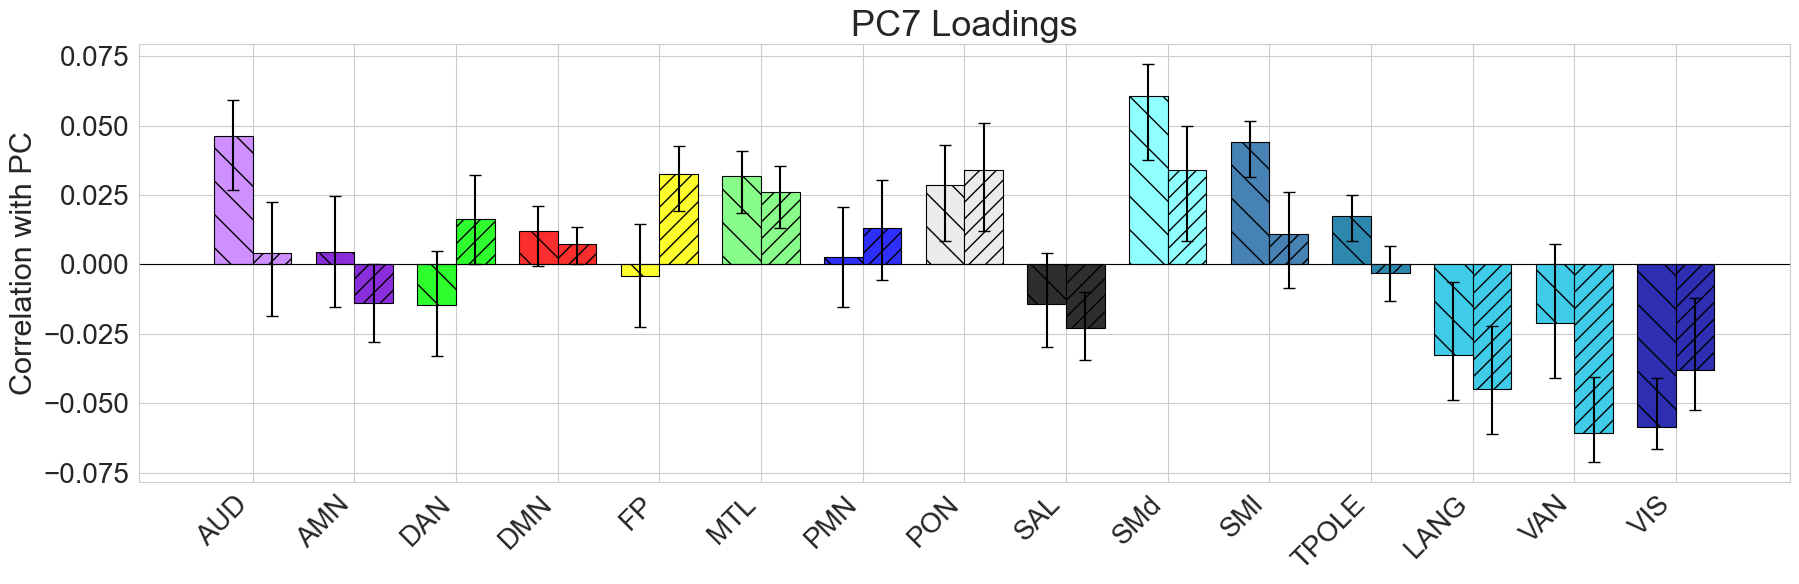


=========== No SES FC PCA PC8 ===========

Top left pMTG features:
  FP_left_L_fz_no_ses_resid: 0.0727 [0.0067, 0.0837]
  FP_right_L_fz_no_ses_resid: 0.0615 [0.0075, 0.0703]
  DAN_left_L_fz_no_ses_resid: -0.0296 [-0.0383, 0.0010]
  Tpole_left_L_fz_no_ses_resid: -0.0287 [-0.0409, 0.0001]
  Tpole_right_L_fz_no_ses_resid: -0.0276 [-0.0416, 0.0034]
  DAN_right_L_fz_no_ses_resid: -0.0273 [-0.0341, -0.0035]
  SMl_right_L_fz_no_ses_resid: 0.0242 [-0.0279, 0.0517]
  SMd_left_L_fz_no_ses_resid: -0.0240 [-0.0367, -0.0009]
  SMd_right_L_fz_no_ses_resid: -0.0237 [-0.0368, -0.0003]
  SMl_left_L_fz_no_ses_resid: 0.0232 [-0.0310, 0.0536]
  PMN_right_L_fz_no_ses_resid: 0.0182 [-0.0005, 0.0289]
  PON_left_L_fz_no_ses_resid: -0.0180 [-0.0289, 0.0064]

Top right pMTG features:
  Sal_right_R_fz_no_ses_resid: -0.0418 [-0.0484, -0.0087]
  FP_right_R_fz_no_ses_resid: -0.0413 [-0.0764, 0.0359]
  SMl_right_R_fz_no_ses_resid: 0.0379 [-0.0036, 0.0482]
  Sal_left_R_fz_no_ses_resid: -0.0374 [-0.0454, -0.0085]
  S

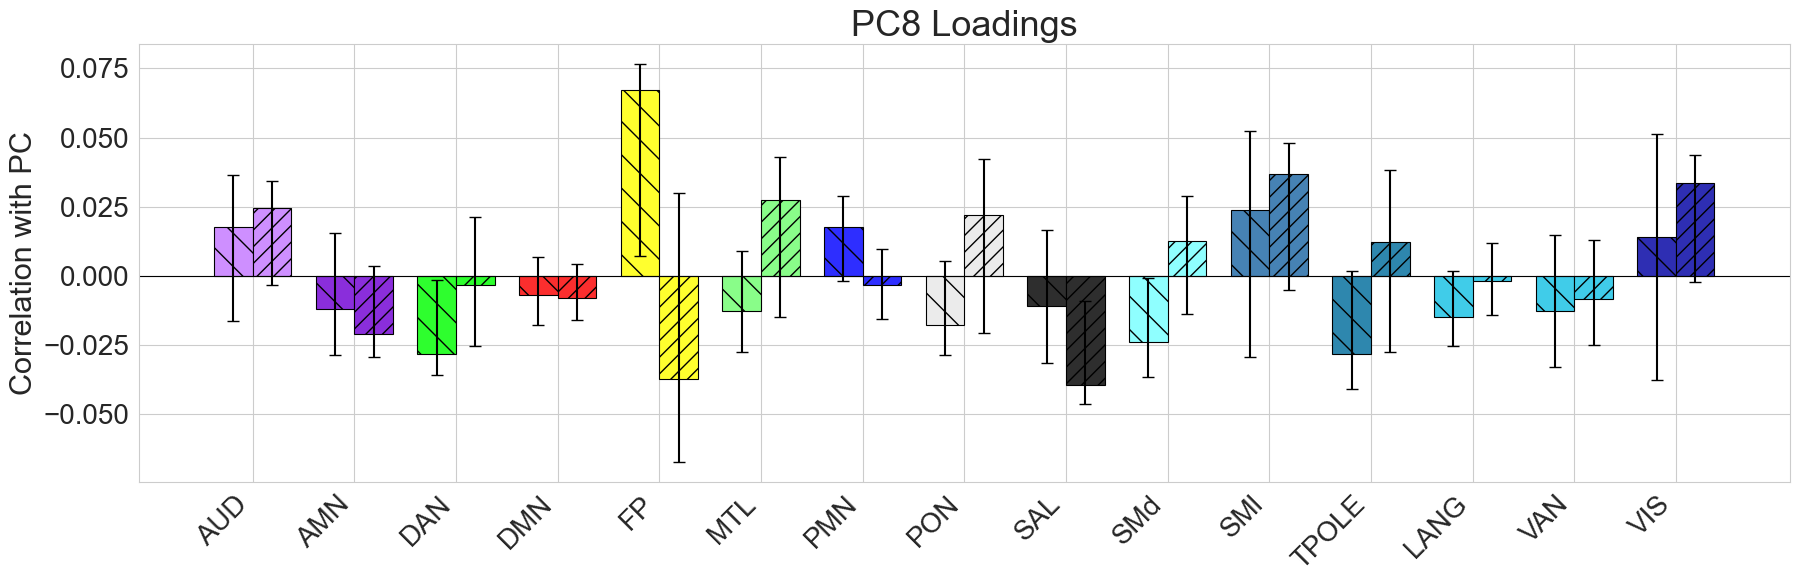


=========== No SES FC PCA PC9 ===========

Top left pMTG features:
  Vis_left_L_fz_no_ses_resid: 0.0514 [0.0041, 0.0575]
  Vis_right_L_fz_no_ses_resid: 0.0502 [0.0053, 0.0557]
  SMl_left_L_fz_no_ses_resid: 0.0477 [-0.0016, 0.0561]
  SMl_right_L_fz_no_ses_resid: 0.0448 [-0.0035, 0.0534]
  Aud_right_L_fz_no_ses_resid: 0.0277 [-0.0085, 0.0388]
  Aud_left_L_fz_no_ses_resid: 0.0269 [-0.0104, 0.0395]
  CO_left_L_fz_no_ses_resid: -0.0266 [-0.0334, 0.0021]
  FP_left_L_fz_no_ses_resid: -0.0253 [-0.0752, 0.0498]
  Sal_left_L_fz_no_ses_resid: -0.0249 [-0.0426, 0.0143]
  Sal_right_L_fz_no_ses_resid: -0.0219 [-0.0327, 0.0063]
  CO_right_L_fz_no_ses_resid: -0.0218 [-0.0284, 0.0031]
  FP_right_L_fz_no_ses_resid: -0.0200 [-0.0624, 0.0429]

Top right pMTG features:
  FP_right_R_fz_no_ses_resid: 0.0604 [-0.0167, 0.0796]
  FP_left_R_fz_no_ses_resid: 0.0424 [-0.0176, 0.0612]
  Tpole_right_R_fz_no_ses_resid: -0.0353 [-0.0485, 0.0037]
  PON_right_R_fz_no_ses_resid: -0.0345 [-0.0439, 0.0039]
  PON_left_R_fz

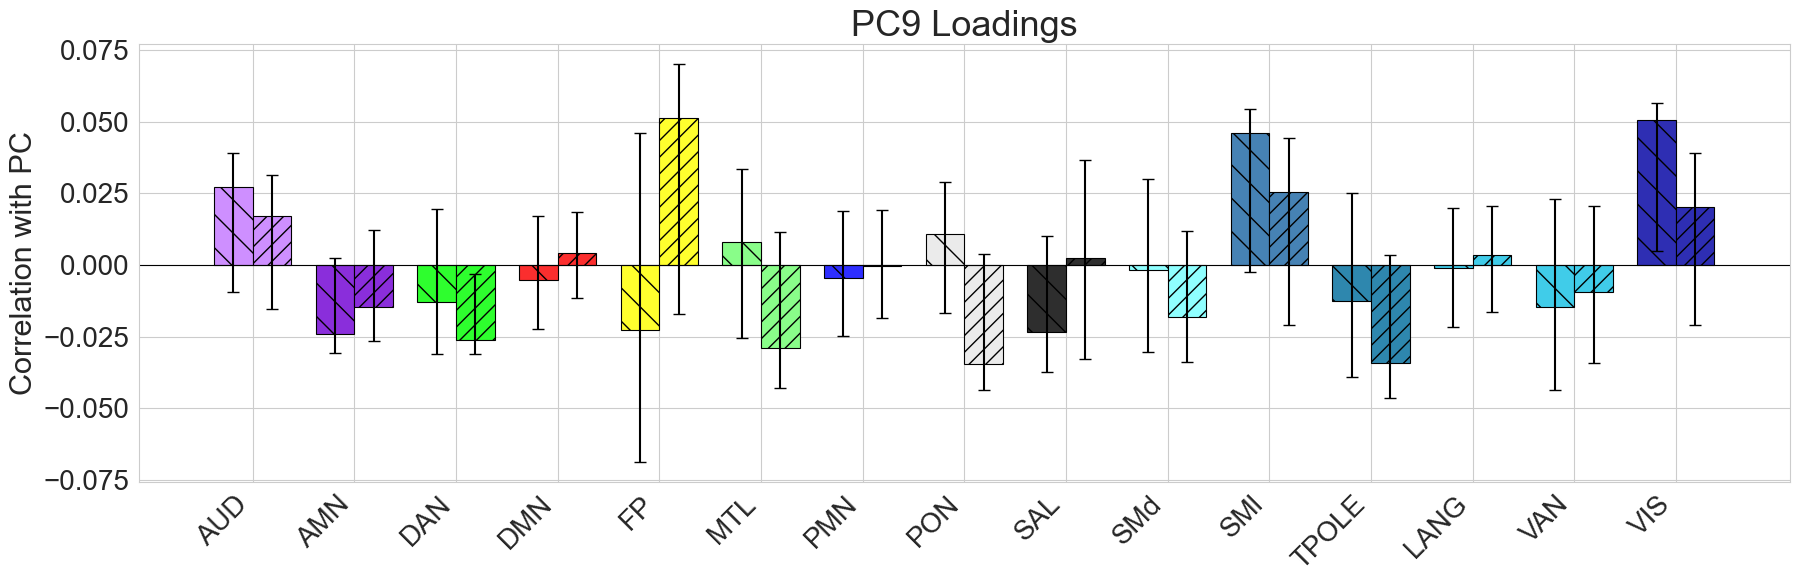


=========== No SES FC PCA PC10 ===========

Top left pMTG features:
  VAN_right_L_fz_no_ses_resid: 0.0455 [0.0149, 0.0587]
  MTL_right_L_fz_no_ses_resid: 0.0414 [0.0204, 0.0485]
  MTL_left_L_fz_no_ses_resid: 0.0385 [0.0180, 0.0464]
  SMd_right_L_fz_no_ses_resid: -0.0363 [-0.0447, -0.0151]
  Tpole_right_L_fz_no_ses_resid: 0.0363 [0.0112, 0.0477]
  SMd_left_L_fz_no_ses_resid: -0.0346 [-0.0427, -0.0143]
  Sal_left_L_fz_no_ses_resid: -0.0346 [-0.0470, -0.0086]
  FP_left_L_fz_no_ses_resid: 0.0329 [-0.0073, 0.0560]
  DMN_left_L_fz_no_ses_resid: -0.0298 [-0.0345, -0.0149]
  Tpole_left_L_fz_no_ses_resid: 0.0288 [0.0054, 0.0426]
  PON_right_L_fz_no_ses_resid: 0.0283 [0.0089, 0.0386]
  DMN_right_L_fz_no_ses_resid: -0.0253 [-0.0302, -0.0119]

Top right pMTG features:
  FP_right_R_fz_no_ses_resid: 0.0376 [-0.0095, 0.0699]
  VAN_right_R_fz_no_ses_resid: 0.0375 [0.0137, 0.0475]
  FP_left_R_fz_no_ses_resid: 0.0353 [-0.0004, 0.0566]
  Tpole_right_R_fz_no_ses_resid: 0.0306 [-0.0033, 0.0457]
  PMN_left

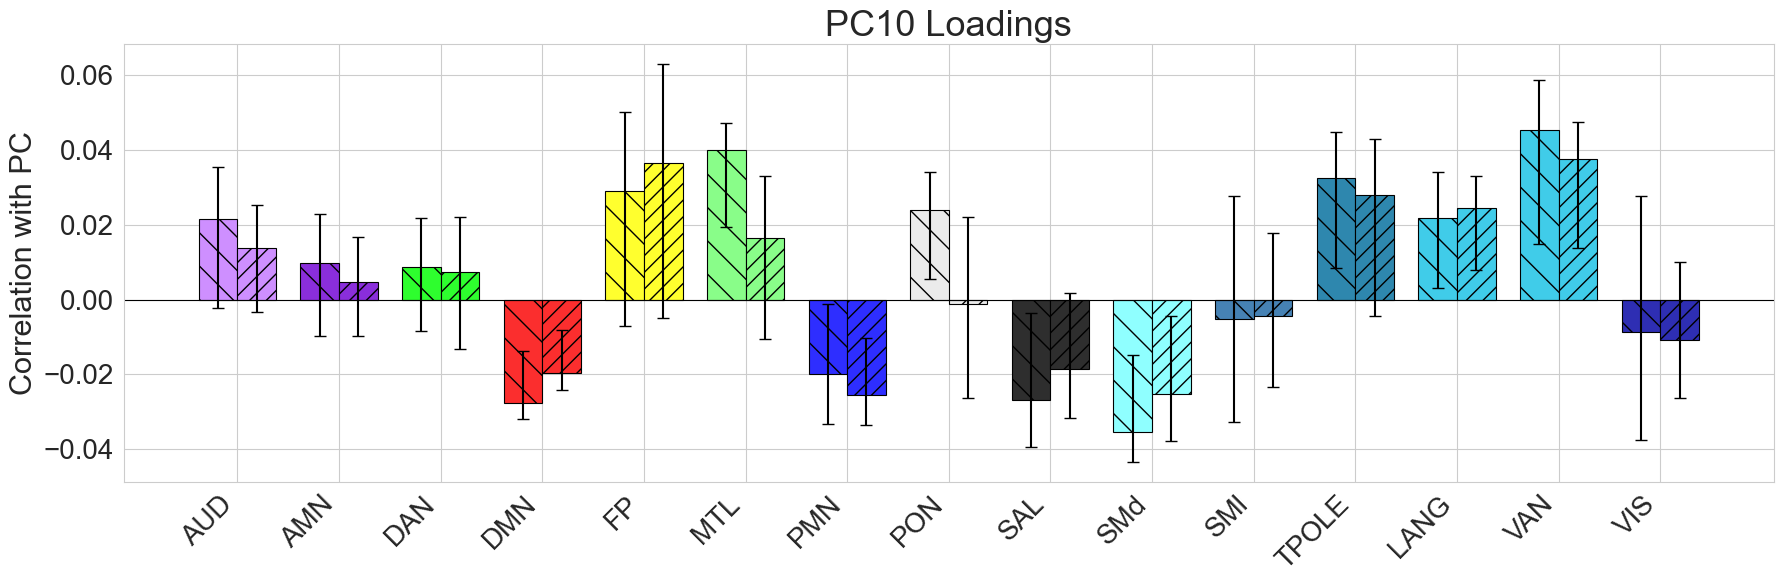

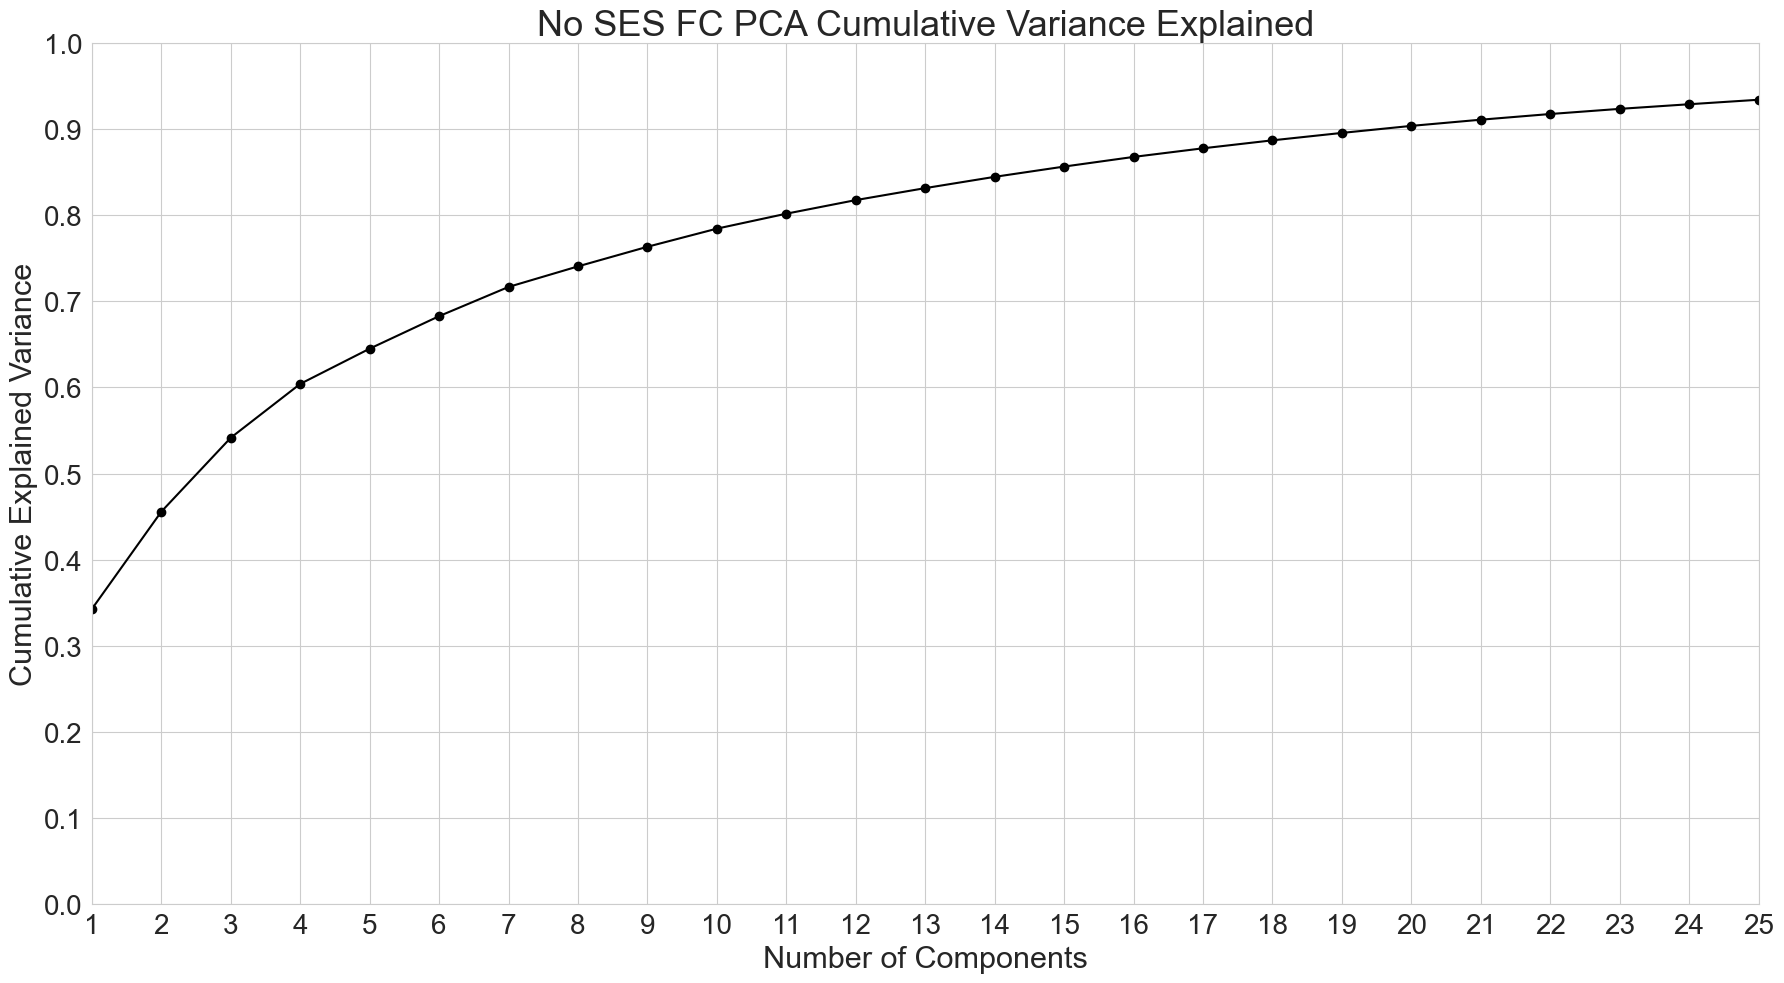

No SES FC PCA variance explained by each component:
Component 1: 0.3426 (34.26%)
Component 2: 0.1131 (11.31%)
Component 3: 0.0859 (8.59%)
Component 4: 0.0626 (6.26%)
Component 5: 0.0409 (4.09%)
Component 6: 0.0378 (3.78%)
Component 7: 0.0340 (3.40%)
Component 8: 0.0239 (2.39%)
Component 9: 0.0228 (2.28%)
Component 10: 0.0211 (2.11%)
Component 11: 0.0174 (1.74%)
Component 12: 0.0158 (1.58%)
Component 13: 0.0139 (1.39%)
Component 14: 0.0131 (1.31%)
Component 15: 0.0119 (1.19%)
Component 16: 0.0112 (1.12%)
Component 17: 0.0100 (1.00%)
Component 18: 0.0093 (0.93%)
Component 19: 0.0086 (0.86%)
Component 20: 0.0082 (0.82%)
Component 21: 0.0072 (0.72%)
Component 22: 0.0066 (0.66%)
Component 23: 0.0060 (0.60%)
Component 24: 0.0054 (0.54%)
Component 25: 0.0052 (0.52%)
Component 26: 0.0049 (0.49%)
Component 27: 0.0044 (0.44%)
Component 28: 0.0043 (0.43%)
Component 29: 0.0041 (0.41%)
Component 30: 0.0039 (0.39%)
Component 31: 0.0037 (0.37%)
Component 32: 0.0037 (0.37%)
Component 33: 0.0031 (0.31%

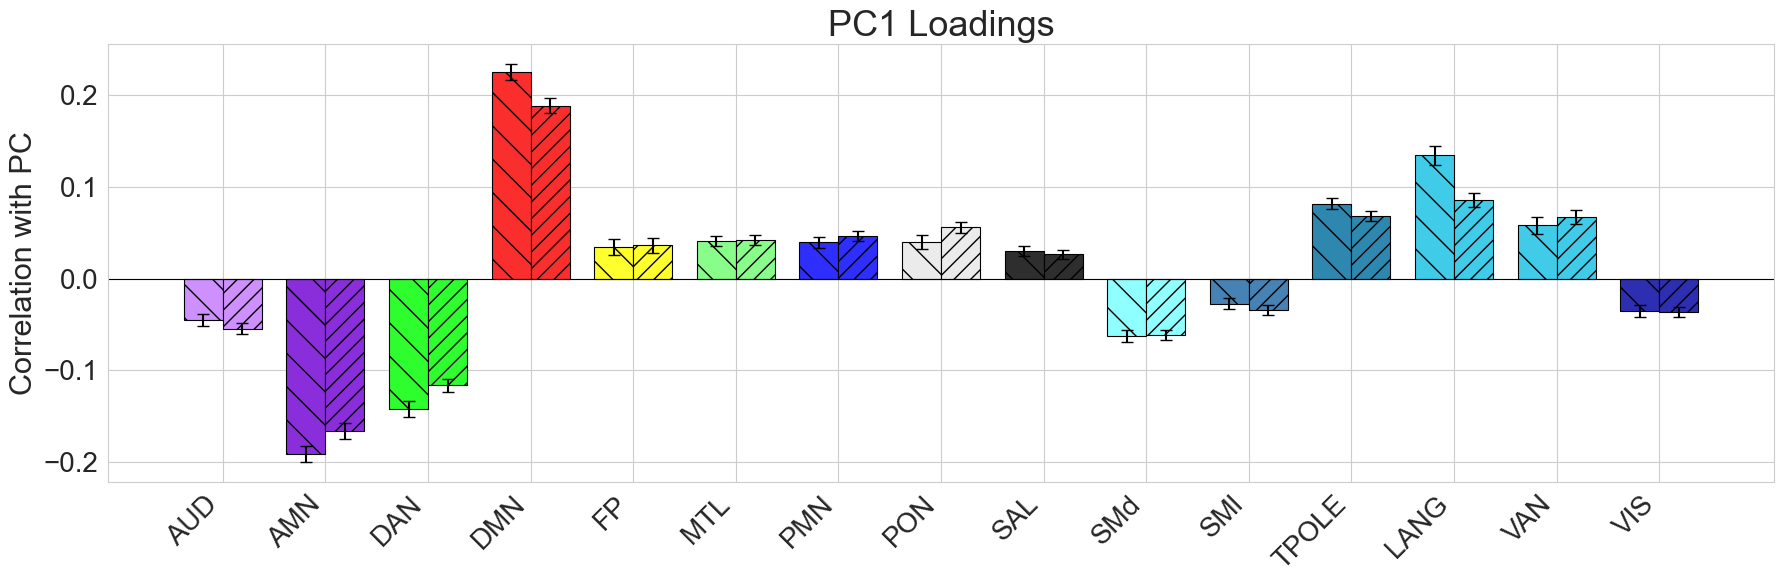


=========== SES FC PCA PC2 ===========

Top left pMTG features:
  VAN_left_L_fz_ses_resid: 0.1373 [0.1280, 0.1450]
  VAN_right_L_fz_ses_resid: 0.1175 [0.1097, 0.1241]
  DAN_left_L_fz_ses_resid: -0.1111 [-0.1192, -0.1013]
  DAN_right_L_fz_ses_resid: -0.1018 [-0.1103, -0.0914]
  Aud_right_L_fz_ses_resid: 0.0737 [0.0622, 0.0832]
  Aud_left_L_fz_ses_resid: 0.0730 [0.0613, 0.0827]
  PON_right_L_fz_ses_resid: -0.0622 [-0.0737, -0.0494]
  PON_left_L_fz_ses_resid: -0.0604 [-0.0723, -0.0473]
  Tpole_left_L_fz_ses_resid: 0.0583 [0.0501, 0.0657]
  FP_left_L_fz_ses_resid: -0.0580 [-0.0712, -0.0438]
  DMN_left_L_fz_ses_resid: 0.0538 [0.0351, 0.0712]
  Sal_left_L_fz_ses_resid: 0.0537 [0.0461, 0.0606]

Top right pMTG features:
  CO_right_R_fz_ses_resid: 0.0826 [0.0663, 0.0968]
  CO_left_R_fz_ses_resid: 0.0825 [0.0691, 0.0939]
  Aud_right_R_fz_ses_resid: 0.0729 [0.0664, 0.0786]
  FP_right_R_fz_ses_resid: -0.0714 [-0.0830, -0.0589]
  Aud_left_R_fz_ses_resid: 0.0674 [0.0611, 0.0730]
  FP_left_R_fz_ses_

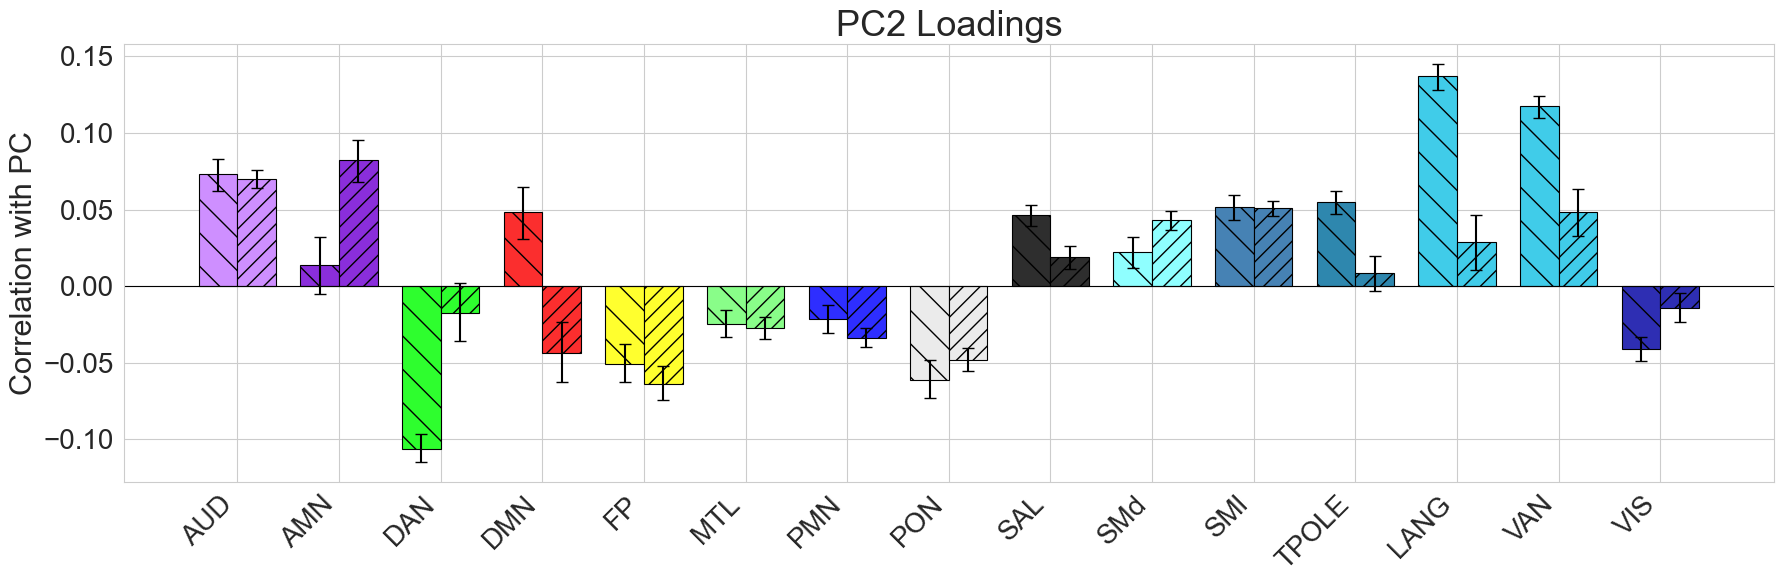


=========== SES FC PCA PC3 ===========

Top left pMTG features:
  CO_left_L_fz_ses_resid: 0.0942 [0.0851, 0.1014]
  CO_right_L_fz_ses_resid: 0.0925 [0.0844, 0.0989]
  DMN_left_L_fz_ses_resid: -0.0895 [-0.0978, -0.0789]
  DMN_right_L_fz_ses_resid: -0.0815 [-0.0885, -0.0724]
  Aud_left_L_fz_ses_resid: 0.0475 [0.0345, 0.0593]
  Aud_right_L_fz_ses_resid: 0.0455 [0.0323, 0.0575]
  PON_left_L_fz_ses_resid: -0.0447 [-0.0584, -0.0297]
  PON_right_L_fz_ses_resid: -0.0429 [-0.0568, -0.0279]
  SMd_left_L_fz_ses_resid: 0.0416 [0.0333, 0.0491]
  SMd_right_L_fz_ses_resid: 0.0395 [0.0311, 0.0471]
  SMl_left_L_fz_ses_resid: 0.0343 [0.0245, 0.0434]
  SMl_right_L_fz_ses_resid: 0.0324 [0.0227, 0.0415]

Top right pMTG features:
  DMN_left_R_fz_ses_resid: 0.1038 [0.0951, 0.1101]
  DAN_right_R_fz_ses_resid: -0.0973 [-0.1042, -0.0888]
  DMN_right_R_fz_ses_resid: 0.0970 [0.0874, 0.1042]
  DAN_left_R_fz_ses_resid: -0.0915 [-0.0979, -0.0836]
  VAN_left_R_fz_ses_resid: 0.0883 [0.0787, 0.0961]
  VAN_right_R_fz_s

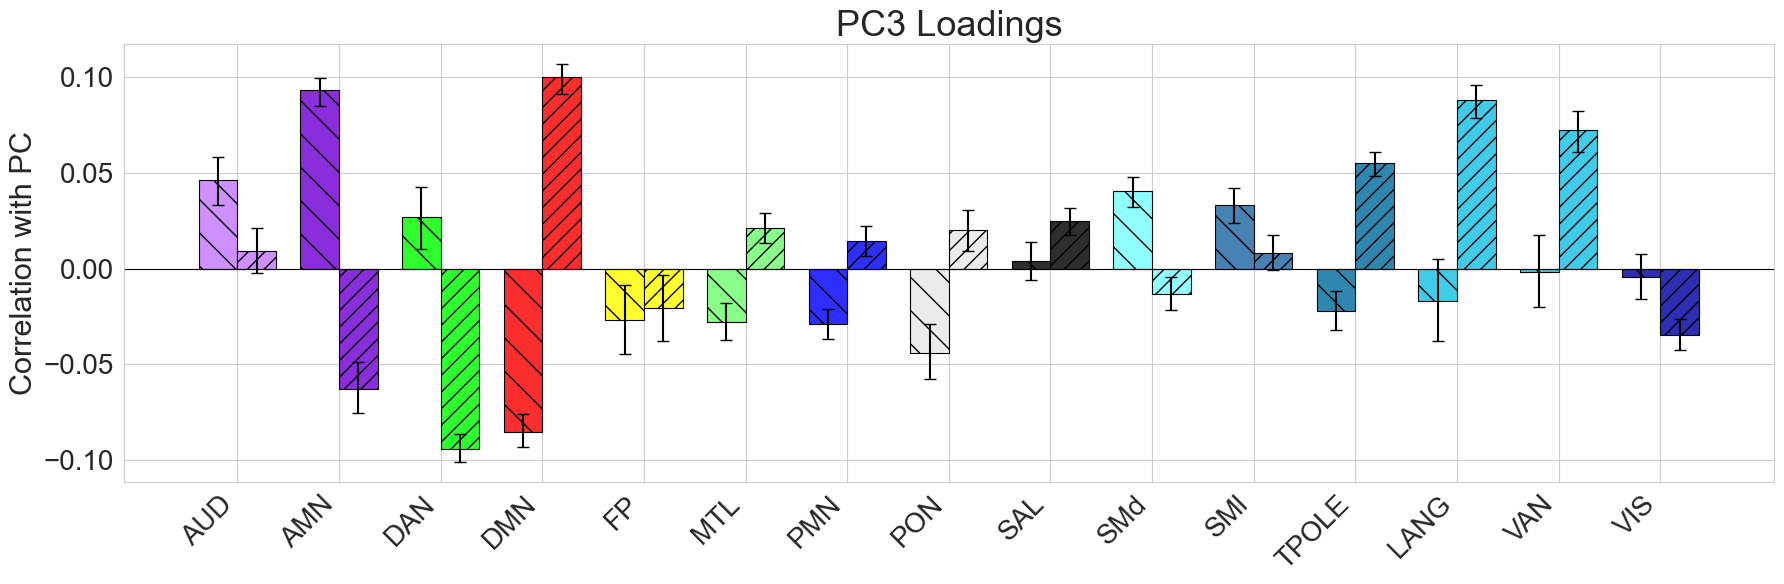


=========== SES FC PCA PC4 ===========

Top left pMTG features:
  FP_left_L_fz_ses_resid: 0.1196 [0.1088, 0.1285]
  FP_right_L_fz_ses_resid: 0.0994 [0.0901, 0.1072]
  PON_left_L_fz_ses_resid: -0.0610 [-0.0725, -0.0482]
  PON_right_L_fz_ses_resid: -0.0606 [-0.0716, -0.0482]
  Vis_right_L_fz_ses_resid: -0.0580 [-0.0658, -0.0493]
  Vis_left_L_fz_ses_resid: -0.0558 [-0.0638, -0.0469]
  MTL_right_L_fz_ses_resid: -0.0525 [-0.0598, -0.0440]
  MTL_left_L_fz_ses_resid: -0.0519 [-0.0596, -0.0432]
  Sal_right_L_fz_ses_resid: 0.0384 [0.0296, 0.0462]
  Sal_left_L_fz_ses_resid: 0.0382 [0.0284, 0.0469]
  Tpole_left_L_fz_ses_resid: -0.0366 [-0.0436, -0.0290]
  Tpole_right_L_fz_ses_resid: -0.0360 [-0.0429, -0.0285]

Top right pMTG features:
  FP_right_R_fz_ses_resid: 0.1030 [0.0928, 0.1114]
  FP_left_R_fz_ses_resid: 0.0929 [0.0843, 0.1000]
  Vis_right_R_fz_ses_resid: -0.0436 [-0.0517, -0.0347]
  PON_left_R_fz_ses_resid: -0.0411 [-0.0490, -0.0325]
  MTL_left_R_fz_ses_resid: -0.0406 [-0.0468, -0.0337]
 

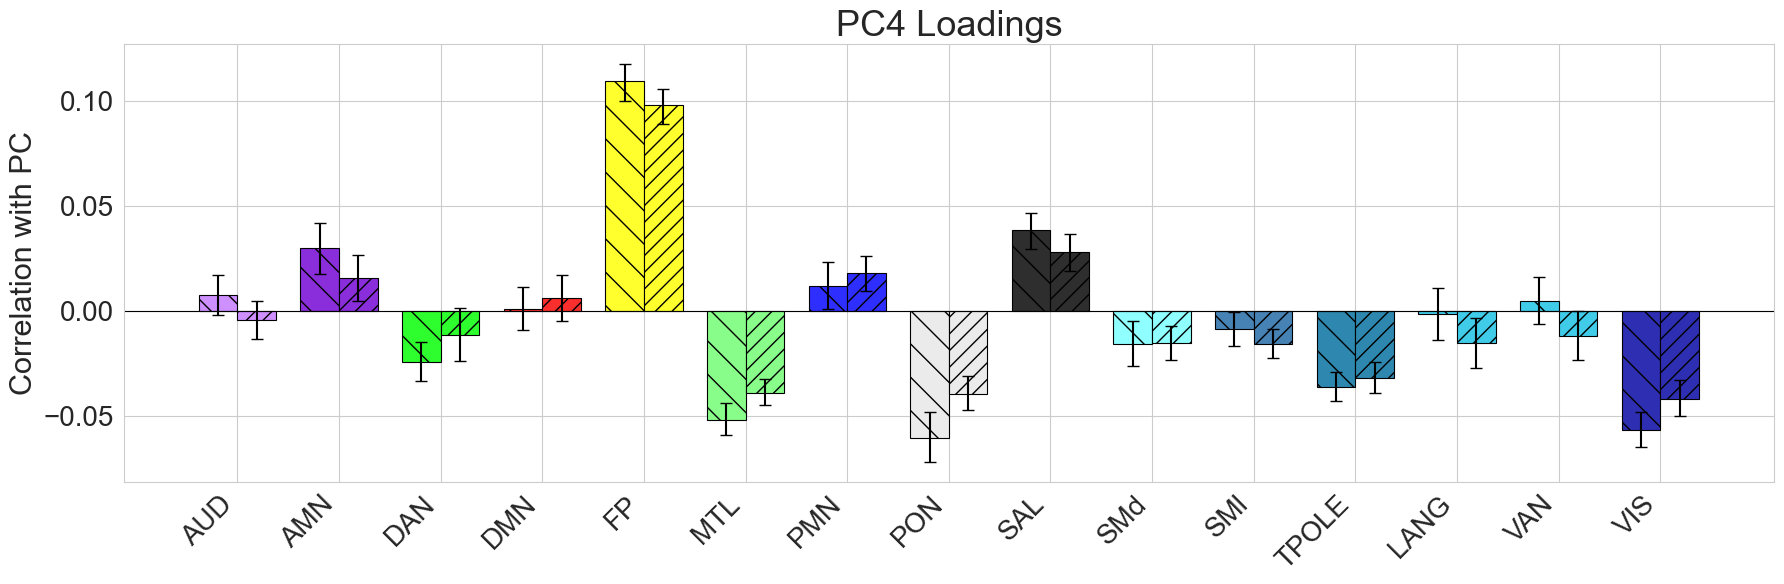


=========== SES FC PCA PC5 ===========

Top left pMTG features:
  PON_left_L_fz_ses_resid: 0.0743 [0.0479, 0.0835]
  PMN_left_L_fz_ses_resid: 0.0734 [0.0387, 0.0815]
  PON_right_L_fz_ses_resid: 0.0708 [0.0455, 0.0799]
  PMN_right_L_fz_ses_resid: 0.0707 [0.0389, 0.0778]
  VAN_left_L_fz_ses_resid: -0.0484 [-0.0648, -0.0167]
  SMd_right_L_fz_ses_resid: -0.0420 [-0.0608, -0.0096]
  SMd_left_L_fz_ses_resid: -0.0387 [-0.0570, -0.0085]
  MTL_left_L_fz_ses_resid: 0.0352 [0.0178, 0.0457]
  Sal_right_L_fz_ses_resid: 0.0347 [0.0053, 0.0484]
  MTL_right_L_fz_ses_resid: 0.0315 [0.0150, 0.0421]
  Sal_left_L_fz_ses_resid: 0.0296 [-0.0034, 0.0479]
  VAN_right_L_fz_ses_resid: -0.0275 [-0.0551, 0.0085]

Top right pMTG features:
  CO_right_R_fz_ses_resid: 0.0531 [0.0316, 0.0605]
  CO_left_R_fz_ses_resid: 0.0523 [0.0289, 0.0608]
  DAN_right_R_fz_ses_resid: -0.0515 [-0.0623, -0.0253]
  DAN_left_R_fz_ses_resid: -0.0479 [-0.0599, -0.0214]
  Sal_left_R_fz_ses_resid: 0.0463 [0.0272, 0.0545]
  Aud_right_R_fz_s

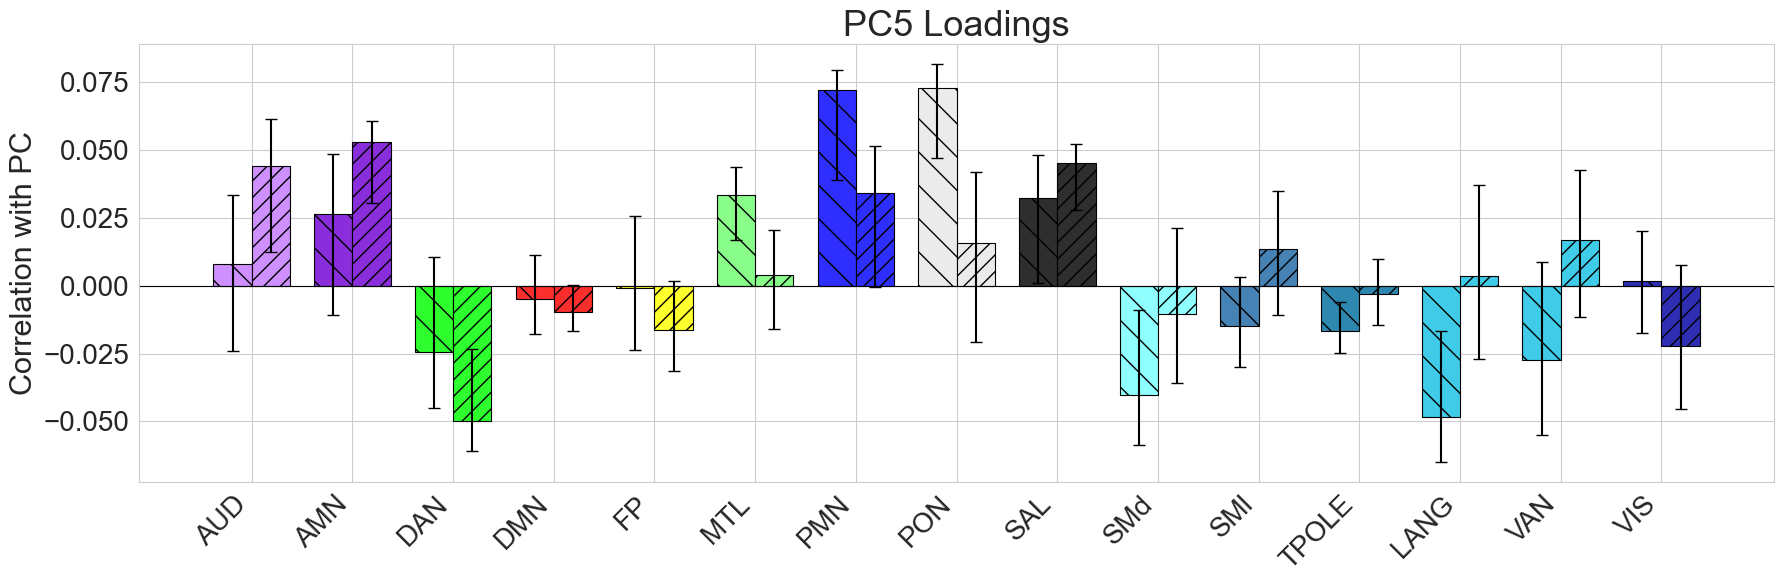


=========== SES FC PCA PC6 ===========

Top left pMTG features:
  VAN_right_L_fz_ses_resid: 0.0516 [0.0159, 0.0655]
  CO_left_L_fz_ses_resid: 0.0488 [0.0225, 0.0571]
  DAN_left_L_fz_ses_resid: -0.0452 [-0.0544, -0.0173]
  CO_right_L_fz_ses_resid: 0.0445 [0.0188, 0.0535]
  Aud_right_L_fz_ses_resid: 0.0422 [0.0021, 0.0600]
  DAN_right_L_fz_ses_resid: -0.0416 [-0.0512, -0.0141]
  Aud_left_L_fz_ses_resid: 0.0406 [0.0030, 0.0570]
  Sal_left_L_fz_ses_resid: 0.0379 [0.0102, 0.0518]
  FP_left_L_fz_ses_resid: -0.0361 [-0.0473, -0.0155]
  VAN_left_L_fz_ses_resid: 0.0355 [-0.0079, 0.0614]
  FP_right_L_fz_ses_resid: -0.0342 [-0.0434, -0.0158]
  Sal_right_L_fz_ses_resid: 0.0309 [0.0043, 0.0466]

Top right pMTG features:
  VAN_left_R_fz_ses_resid: -0.0498 [-0.0631, -0.0111]
  PON_right_R_fz_ses_resid: 0.0488 [0.0146, 0.0594]
  PON_left_R_fz_ses_resid: 0.0463 [0.0124, 0.0579]
  SMd_right_R_fz_ses_resid: -0.0461 [-0.0610, -0.0159]
  Aud_left_R_fz_ses_resid: -0.0421 [-0.0578, -0.0050]
  Aud_right_R_fz

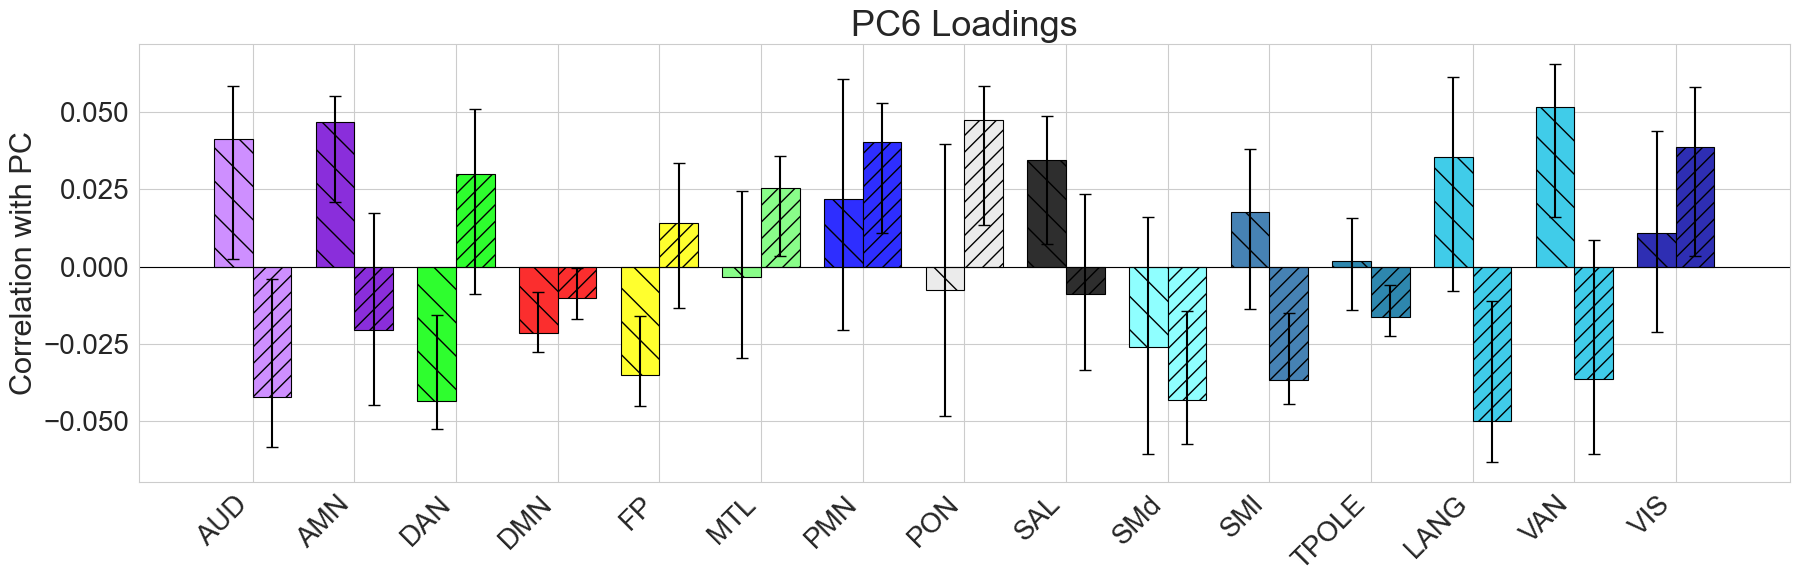


=========== SES FC PCA PC7 ===========

Top left pMTG features:
  SMd_left_L_fz_ses_resid: 0.0621 [0.0343, 0.0730]
  Vis_left_L_fz_ses_resid: -0.0605 [-0.0675, -0.0401]
  SMd_right_L_fz_ses_resid: 0.0591 [0.0301, 0.0713]
  Vis_right_L_fz_ses_resid: -0.0584 [-0.0656, -0.0380]
  Aud_right_L_fz_ses_resid: 0.0482 [0.0221, 0.0634]
  Aud_left_L_fz_ses_resid: 0.0445 [0.0197, 0.0596]
  SMl_left_L_fz_ses_resid: 0.0439 [0.0282, 0.0521]
  SMl_right_L_fz_ses_resid: 0.0418 [0.0256, 0.0503]
  VAN_left_L_fz_ses_resid: -0.0358 [-0.0517, -0.0056]
  MTL_left_L_fz_ses_resid: 0.0357 [0.0195, 0.0445]
  MTL_right_L_fz_ses_resid: 0.0332 [0.0179, 0.0418]
  PON_left_L_fz_ses_resid: 0.0317 [0.0092, 0.0469]

Top right pMTG features:
  VAN_right_R_fz_ses_resid: -0.0568 [-0.0694, -0.0313]
  Vis_left_R_fz_ses_resid: -0.0427 [-0.0565, -0.0120]
  Vis_right_R_fz_ses_resid: -0.0416 [-0.0554, -0.0109]
  VAN_left_R_fz_ses_resid: -0.0395 [-0.0601, -0.0109]
  SMd_right_R_fz_ses_resid: 0.0377 [0.0051, 0.0550]
  SMd_left_R_

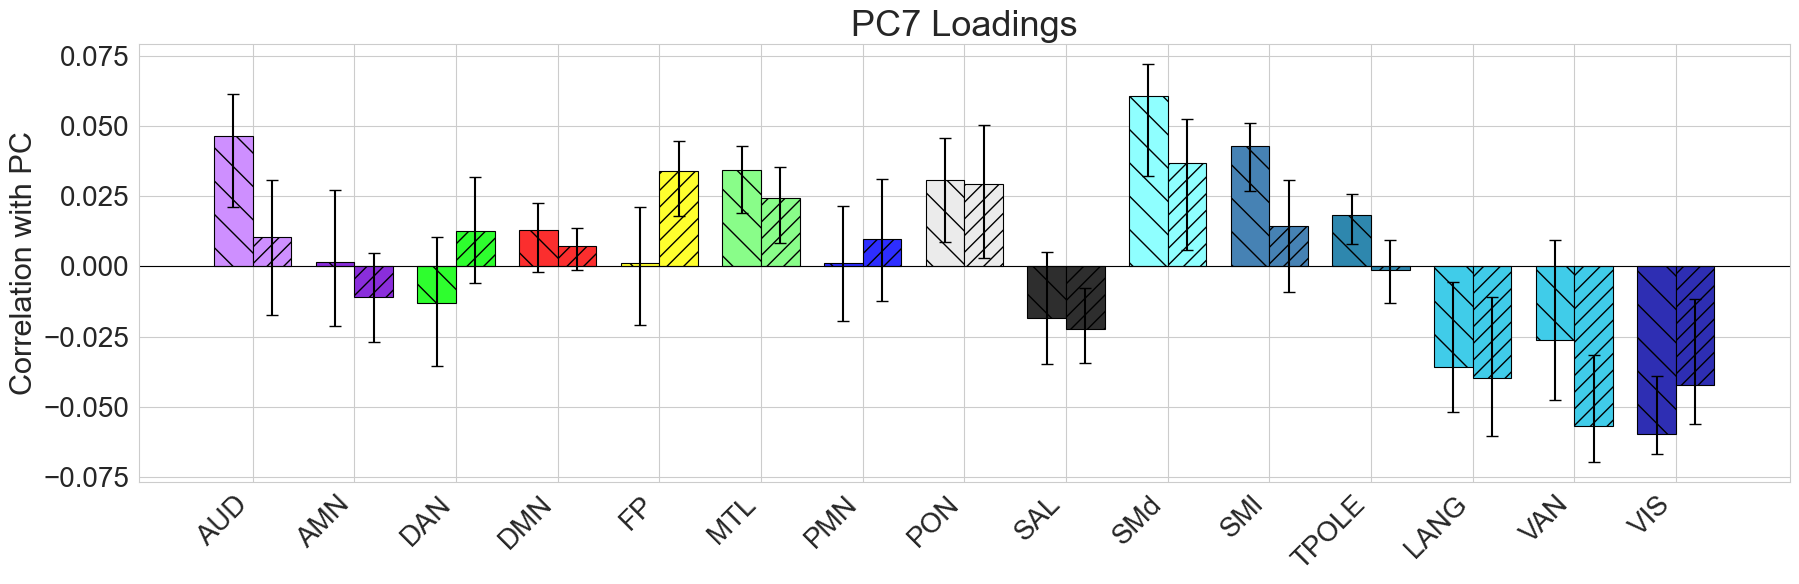


=========== SES FC PCA PC8 ===========

Top left pMTG features:
  FP_left_L_fz_ses_resid: 0.0788 [0.0146, 0.0870]
  FP_right_L_fz_ses_resid: 0.0656 [0.0142, 0.0718]
  DAN_left_L_fz_ses_resid: -0.0262 [-0.0377, 0.0062]
  DAN_right_L_fz_ses_resid: -0.0256 [-0.0343, 0.0007]
  SMd_right_L_fz_ses_resid: -0.0254 [-0.0381, -0.0018]
  SMd_left_L_fz_ses_resid: -0.0253 [-0.0379, -0.0018]
  Tpole_left_L_fz_ses_resid: -0.0244 [-0.0391, 0.0063]
  Tpole_right_L_fz_ses_resid: -0.0223 [-0.0392, 0.0097]
  PON_left_L_fz_ses_resid: -0.0195 [-0.0296, 0.0038]
  PON_right_L_fz_ses_resid: -0.0185 [-0.0293, 0.0019]
  SMl_right_L_fz_ses_resid: 0.0184 [-0.0299, 0.0495]
  SMl_left_L_fz_ses_resid: 0.0168 [-0.0335, 0.0510]

Top right pMTG features:
  FP_right_R_fz_ses_resid: -0.0483 [-0.0759, 0.0265]
  Sal_right_R_fz_ses_resid: -0.0416 [-0.0479, -0.0108]
  FP_left_R_fz_ses_resid: -0.0377 [-0.0579, 0.0163]
  Sal_left_R_fz_ses_resid: -0.0362 [-0.0446, -0.0085]
  SMl_right_R_fz_ses_resid: 0.0325 [-0.0102, 0.0468]
  

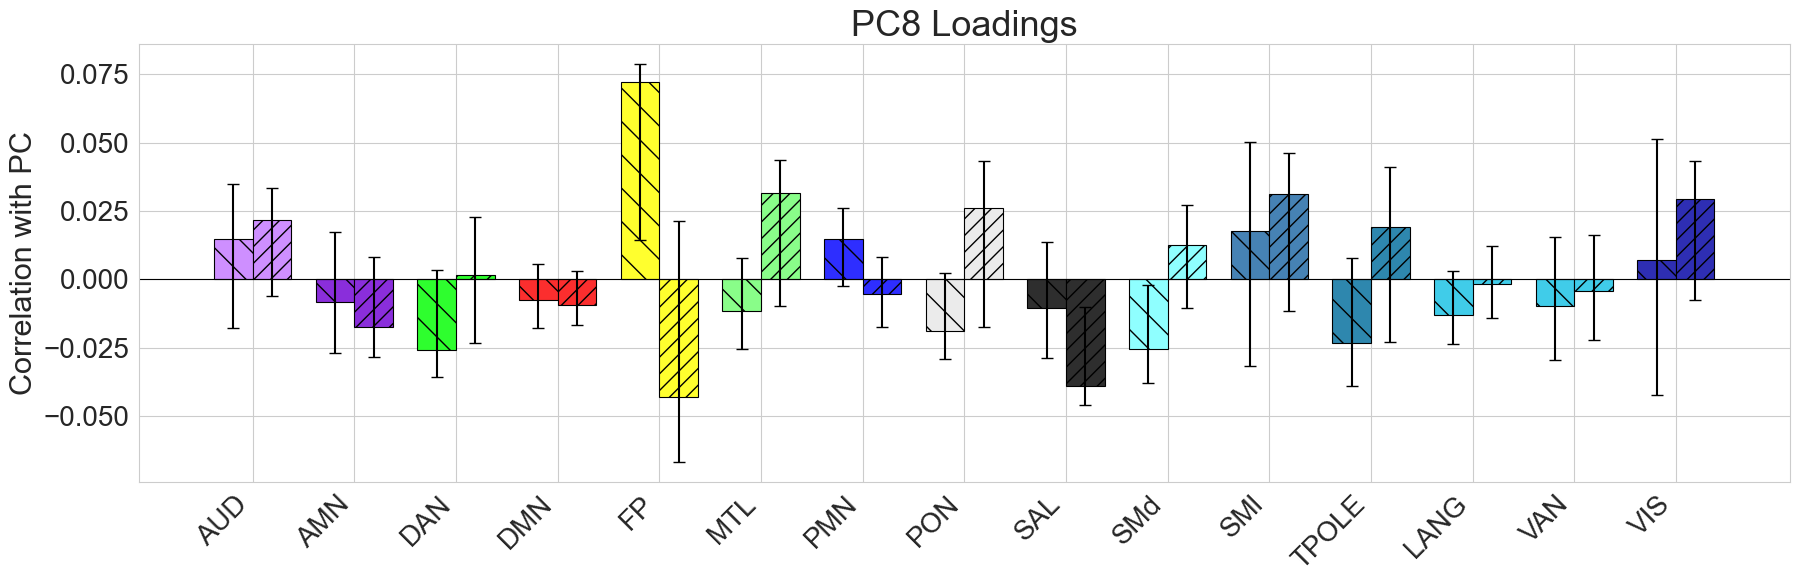


=========== SES FC PCA PC9 ===========

Top left pMTG features:
  Vis_left_L_fz_ses_resid: 0.0545 [0.0101, 0.0590]
  Vis_right_L_fz_ses_resid: 0.0534 [0.0105, 0.0575]
  SMl_left_L_fz_ses_resid: 0.0483 [0.0040, 0.0550]
  SMl_right_L_fz_ses_resid: 0.0455 [0.0017, 0.0524]
  Aud_right_L_fz_ses_resid: 0.0291 [-0.0042, 0.0387]
  Aud_left_L_fz_ses_resid: 0.0280 [-0.0057, 0.0389]
  CO_left_L_fz_ses_resid: -0.0269 [-0.0329, -0.0019]
  CO_right_L_fz_ses_resid: -0.0221 [-0.0281, 0.0001]
  Sal_left_L_fz_ses_resid: -0.0218 [-0.0389, 0.0115]
  DAN_left_L_fz_ses_resid: -0.0217 [-0.0358, 0.0141]
  Tpole_right_L_fz_ses_resid: -0.0199 [-0.0428, 0.0181]
  Sal_right_L_fz_ses_resid: -0.0190 [-0.0300, 0.0052]

Top right pMTG features:
  FP_right_R_fz_ses_resid: 0.0525 [-0.0218, 0.0768]
  FP_left_R_fz_ses_resid: 0.0359 [-0.0205, 0.0582]
  Tpole_right_R_fz_ses_resid: -0.0345 [-0.0496, 0.0057]
  PON_right_R_fz_ses_resid: -0.0320 [-0.0436, 0.0073]
  SMl_left_R_fz_ses_resid: 0.0316 [-0.0130, 0.0447]
  PON_left_

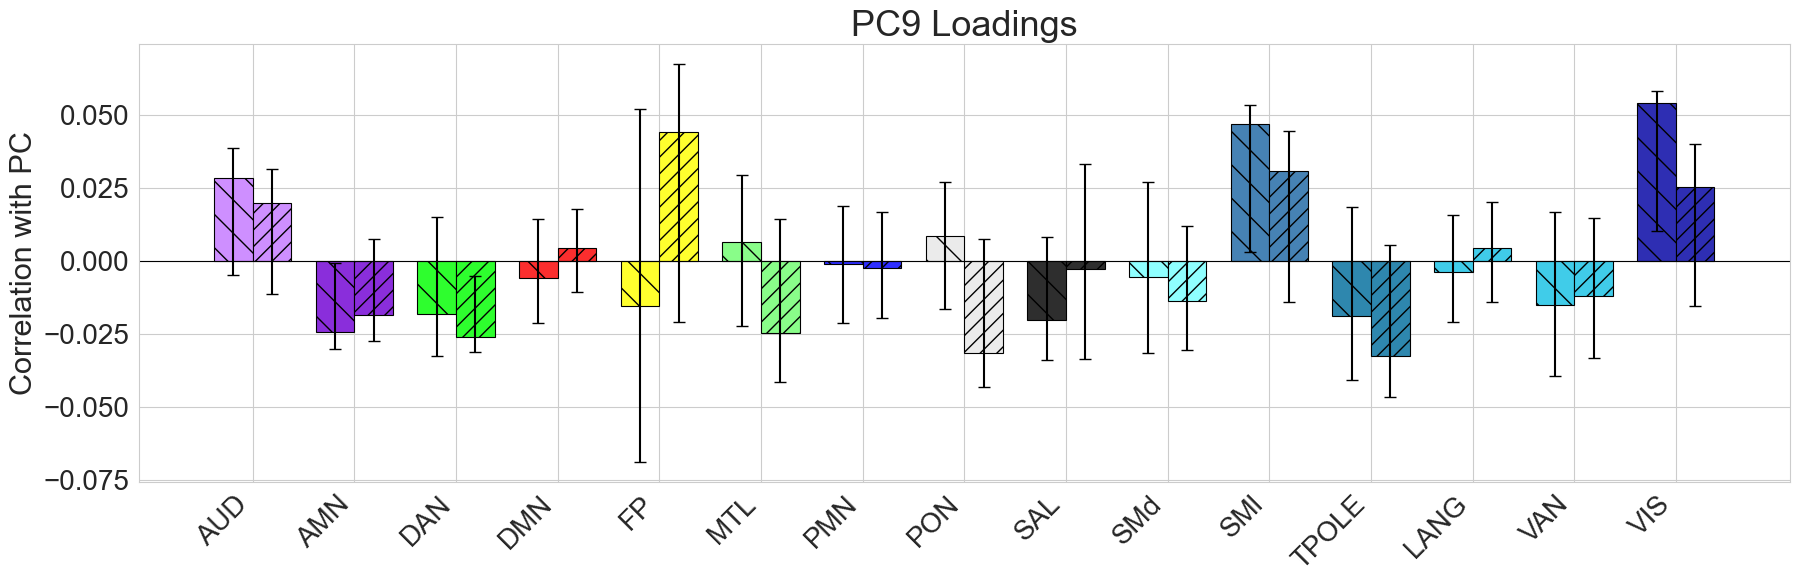


=========== SES FC PCA PC10 ===========

Top left pMTG features:
  VAN_right_L_fz_ses_resid: 0.0428 [0.0136, 0.0572]
  MTL_right_L_fz_ses_resid: 0.0404 [0.0229, 0.0481]
  Tpole_right_L_fz_ses_resid: 0.0388 [0.0160, 0.0501]
  MTL_left_L_fz_ses_resid: 0.0386 [0.0210, 0.0469]
  SMd_right_L_fz_ses_resid: -0.0362 [-0.0447, -0.0176]
  SMd_left_L_fz_ses_resid: -0.0345 [-0.0430, -0.0164]
  Sal_left_L_fz_ses_resid: -0.0329 [-0.0451, -0.0105]
  Tpole_left_L_fz_ses_resid: 0.0311 [0.0090, 0.0450]
  DMN_left_L_fz_ses_resid: -0.0297 [-0.0348, -0.0169]
  FP_left_L_fz_ses_resid: 0.0288 [-0.0047, 0.0505]
  PON_right_L_fz_ses_resid: 0.0274 [0.0092, 0.0379]
  DMN_right_L_fz_ses_resid: -0.0253 [-0.0307, -0.0131]

Top right pMTG features:
  FP_right_R_fz_ses_resid: 0.0403 [0.0031, 0.0667]
  FP_left_R_fz_ses_resid: 0.0373 [0.0092, 0.0547]
  VAN_right_R_fz_ses_resid: 0.0370 [0.0139, 0.0480]
  Tpole_right_R_fz_ses_resid: 0.0311 [0.0030, 0.0455]
  PMN_left_R_fz_ses_resid: -0.0300 [-0.0390, -0.0142]
  SMd_righ

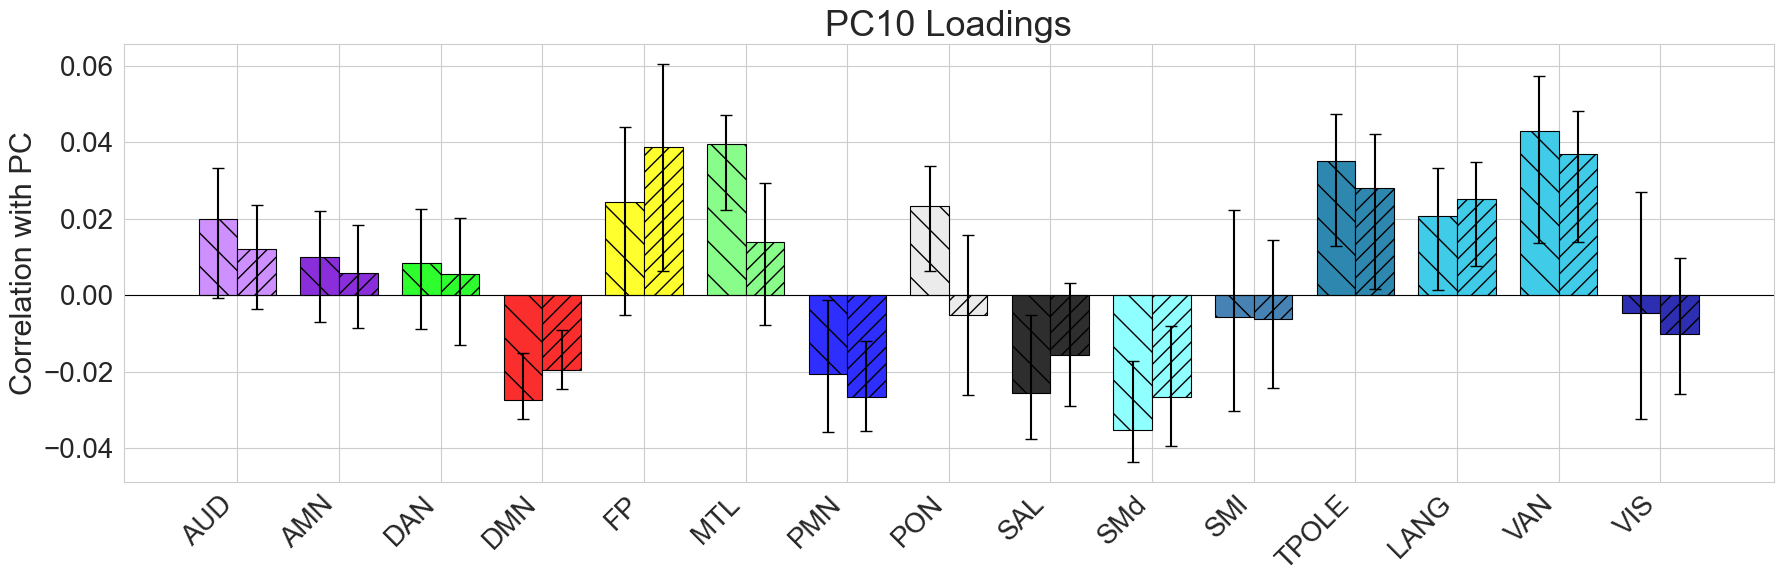

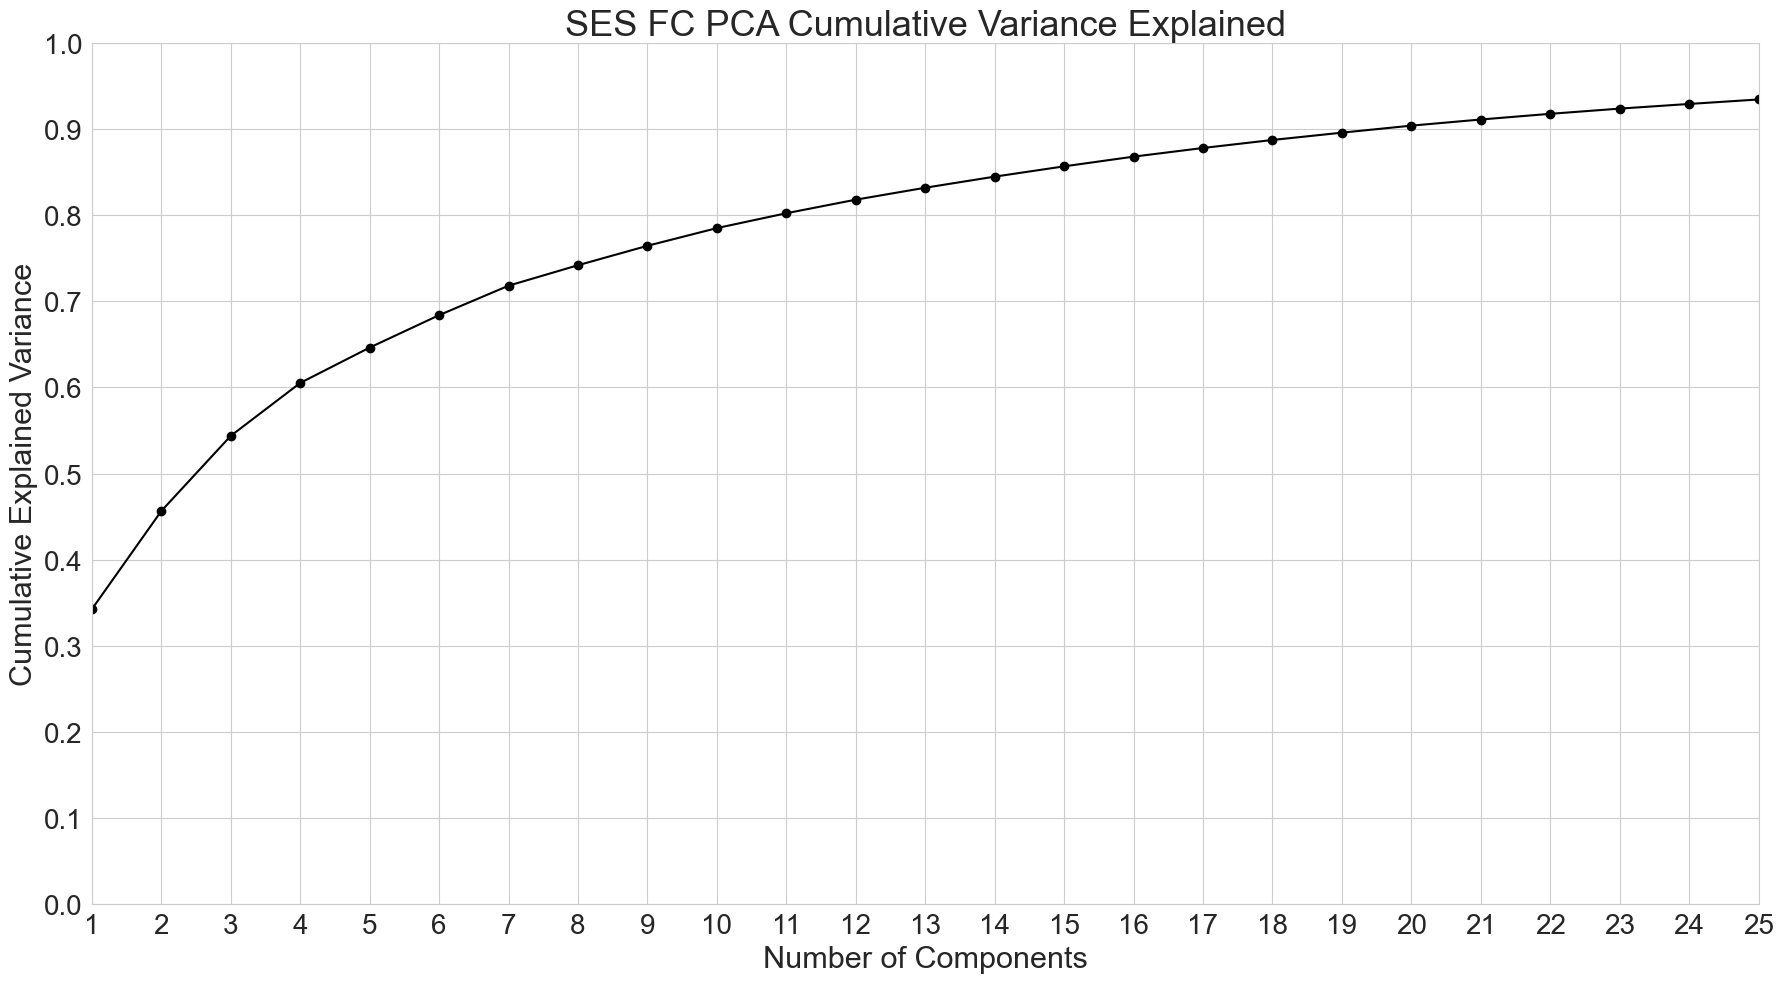

SES FC PCA variance explained by each component:
Component 1: 0.3424 (34.24%)
Component 2: 0.1141 (11.41%)
Component 3: 0.0873 (8.73%)
Component 4: 0.0615 (6.15%)
Component 5: 0.0411 (4.11%)
Component 6: 0.0377 (3.77%)
Component 7: 0.0342 (3.42%)
Component 8: 0.0238 (2.38%)
Component 9: 0.0226 (2.26%)
Component 10: 0.0206 (2.06%)
Component 11: 0.0173 (1.73%)
Component 12: 0.0157 (1.57%)
Component 13: 0.0139 (1.39%)
Component 14: 0.0129 (1.29%)
Component 15: 0.0120 (1.20%)
Component 16: 0.0113 (1.13%)
Component 17: 0.0101 (1.01%)
Component 18: 0.0093 (0.93%)
Component 19: 0.0085 (0.85%)
Component 20: 0.0082 (0.82%)
Component 21: 0.0071 (0.71%)
Component 22: 0.0066 (0.66%)
Component 23: 0.0061 (0.61%)
Component 24: 0.0054 (0.54%)
Component 25: 0.0052 (0.52%)
Component 26: 0.0050 (0.50%)
Component 27: 0.0044 (0.44%)
Component 28: 0.0042 (0.42%)
Component 29: 0.0041 (0.41%)
Component 30: 0.0038 (0.38%)
Component 31: 0.0037 (0.37%)
Component 32: 0.0036 (0.36%)
Component 33: 0.0031 (0.31%)
C

In [18]:
pca_model_outputs = {}

for spec in PCA_MODEL_SPECS:
    # Residualize FC columns based on the specified covariates for this PCA model
    # Then run PCA with bootstrapping to estimate loadings and variance explained
    print('\\n' + '=' * 90)
    print(spec['label'])
    print('=' * 90)
    print('FC covariates:', spec['fc_covariates'])

    df, fc_resid_cols = residualize_fc_variant(
        df,
        raw_fc_cols,
        covariates=spec['fc_covariates'],
        output_suffix=spec['prefix'],
    )
    fc_result = run_fc_pca_with_bootstrap(
        df,
        fc_resid_cols,
        analysis_label=f"{spec['short_label']} FC PCA",
        score_prefix=f"{spec['prefix']}_fc",
        n_boot=N_FC_BOOTSTRAPS,
    )
    df = attach_score_columns(df, fc_result['scores'])


    # Export the fitted FC-PCA coordinates 
    fc_score_export = df[['src_subject_id', *fc_result['score_cols']]].copy()
    if not FULL_NETWORKS:
        fc_score_path = PCA_RESULTS_DIR / f'pca_fc_scores_{spec["model_name"]}.csv'
    else:
        fc_score_path = PCA_RESULTS_DIR / f'pca_fc_scores_fullnetworks_{spec["model_name"]}.csv'
    fc_score_export.to_csv(fc_score_path, index=False)

    fc_variance_export = pd.DataFrame({
        'component': np.arange(1, len(fc_result['var_exp']) + 1),
        'explained_variance_ratio': fc_result['var_exp'],
    })
    fc_variance_path = PCA_RESULTS_DIR / f'pca_fc_variance_{spec["model_name"]}.csv'
    fc_variance_export.to_csv(fc_variance_path, index=False)

    print('Saved FC-PCA scores to:', fc_score_path)
    print('Saved FC-PCA variance to:', fc_variance_path)
    pca_model_outputs[spec['model_name']] = {
        'spec': spec,
        'fc_resid_cols': fc_resid_cols,
        'fc': fc_result,
    }
